## Cell 1: Setup & Configuration

Imports, a fixed random seed (so re-running gives the same numbers), the 2-year date range, and the per-client config table (platforms, follower ranges, posting cadence).

This cell generates nothing yet — it's the scaffolding every later cell reads from.

In [1]:
import random
from datetime import datetime, timedelta

import os
import shutil

import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
import pandas as pd
import numpy as np

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---- Date range: 2 full years ----
START_DATE = datetime(2024, 1, 1)
END_DATE = datetime(2025, 12, 31)
ALL_DATES = pd.date_range(START_DATE, END_DATE, freq='D')

print(f"Date range: {START_DATE.date()} to {END_DATE.date()}")
print(f"Total days: {len(ALL_DATES)}")

# ---- Client configuration — plain editable variables, nothing buried in logic ----
CLIENTS = {
    "chiropractor": {
        "platforms": ["instagram", "facebook"],
        "follower_range": (5_000, 40_000),
        "posts_per_week": (1, 2),
    },
    "real_estate_agent": {
        "platforms": ["facebook", "youtube"],
        "follower_range": (8_000, 70_000),
        "posts_per_week": (1, 2),
    },
    "aesthetician": {
        "platforms": ["instagram", "tiktok"],
        "follower_range": (50_000, 500_000),
        "posts_per_week": (3, 4),
        "has_store": True,  # triggers GA/e-commerce data generation later
    },
    "vlogger": {
        "platforms": ["youtube", "tiktok", "instagram"],
        "follower_range": (200_000, 4_000_000),
        "posts_per_week": (5, 5),
    },
}

# ---- Engagement rate ranges per platform (normal week, applied on top of whichever client is posting there) ----
ENGAGEMENT_RATE_RANGES = {
    "instagram": (0.03, 0.08),
    "facebook":  (0.02, 0.04),
    "youtube":   (0.03, 0.07),
    "tiktok":    (0.05, 0.12),
}

# ---- Print the config back out to confirm it loaded correctly ----
for client, cfg in CLIENTS.items():
    print(f"{client}: {cfg['platforms']}, "
          f"followers {cfg['follower_range'][0]:,}-{cfg['follower_range'][1]:,}, "
          f"{cfg['posts_per_week']} posts/week")

Date range: 2024-01-01 to 2025-12-31
Total days: 731
chiropractor: ['instagram', 'facebook'], followers 5,000-40,000, (1, 2) posts/week
real_estate_agent: ['facebook', 'youtube'], followers 8,000-70,000, (1, 2) posts/week
aesthetician: ['instagram', 'tiktok'], followers 50,000-500,000, (3, 4) posts/week
vlogger: ['youtube', 'tiktok', 'instagram'], followers 200,000-4,000,000, (5, 5) posts/week


## Cell 2: Baseline Post Generator (single client-platform test)

Generates posting dates across the 2-year range based on each client's posts-per-week range, then a baseline reach + engagement-rate + engagement breakdown (likes/comments/shares/saves) per post — no seasonality or anomalies yet, just "normal week" numbers.

Tested here on one client-platform pair (aesthetician + Instagram) to confirm the output before generalizing to a loop over all clients/platforms in the next cell.

In [2]:
def generate_posting_dates(start, end, posts_per_week_range):
    """Pick random posting days within each week, honoring the client's posts-per-week range."""
    dates = []
    current = start
    while current <= end:
        week_end = min(current + timedelta(days=6), end)
        possible_days = list(pd.date_range(current, week_end))
        n_posts = random.randint(*posts_per_week_range)
        n_posts = min(n_posts, len(possible_days))
        chosen = sorted(random.sample(possible_days, n_posts))
        dates.extend(chosen)
        current += timedelta(days=7)
    return dates


def generate_baseline_posts(client_name, platform, follower_count):
    """Generate baseline (no seasonality) post-level rows for one client-platform pair."""
    cfg = CLIENTS[client_name]
    post_dates = generate_posting_dates(START_DATE, END_DATE, cfg["posts_per_week"])

    rows = []
    for date in post_dates:
        eng_rate_range = ENGAGEMENT_RATE_RANGES[platform]
        engagement_rate = random.uniform(*eng_rate_range)

        # Reach as a fraction of follower count — varies by platform reach dynamics
        reach_fraction = random.uniform(0.10, 0.35)
        reach = int(follower_count * reach_fraction)

        total_engagements = int(reach * engagement_rate)

        # Split engagements into likes/comments/shares/saves (rough realistic split)
        likes = int(total_engagements * 0.70)
        comments = int(total_engagements * 0.12)
        shares = int(total_engagements * 0.10)
        saves = total_engagements - likes - comments - shares  # remainder

        rows.append({
            "date": date,
            "client": client_name,
            "platform": platform,
            "reach": reach,
            "likes": likes,
            "comments": comments,
            "shares": shares,
            "saves": saves,
            "total_engagements": total_engagements,
            "engagement_rate": round(engagement_rate, 4),
        })

    return pd.DataFrame(rows)


# ---- Test on one client-platform pair before generalizing ----
test_followers = random.randint(*CLIENTS["aesthetician"]["follower_range"])
test_df = generate_baseline_posts("aesthetician", "instagram", test_followers)

print(f"Test followers: {test_followers:,}")
print(f"Total posts generated: {len(test_df)}")
print(f"Expected range: ~{731//7 * 3} to ~{731//7 * 4} posts (3-4/week over 731 days)")
test_df.head(10)

Test followers: 385,243
Total posts generated: 355
Expected range: ~312 to ~416 posts (3-4/week over 731 days)


,date,client,platform,reach,likes,comments,shares,saves,total_engagements,engagement_rate
0,2024-01-01,aesthetician,instagram,87779,3705,635,529,424,5293,0.0603
1,2024-01-03,aesthetician,instagram,94055,3243,555,463,372,4633,0.0493
2,2024-01-06,aesthetician,instagram,106787,3194,547,456,366,4563,0.0427
3,2024-01-08,aesthetician,instagram,127667,2688,460,384,308,3840,0.0301
4,2024-01-09,aesthetician,instagram,107813,4295,736,613,492,6136,0.0569
5,2024-01-14,aesthetician,instagram,103113,4842,830,691,555,6918,0.0671
6,2024-01-15,aesthetician,instagram,45263,1527,261,218,176,2182,0.0482
7,2024-01-18,aesthetician,instagram,70326,3111,533,444,357,4445,0.0632
8,2024-01-19,aesthetician,instagram,120197,3844,659,549,440,5492,0.0457
9,2024-01-22,aesthetician,instagram,67448,3115,534,445,356,4450,0.0660


## Cell 3: Generate Baseline Data for All Clients & Platforms

Loops the Cell 2 functions over every client and their assigned platforms (from the CLIENTS config), assigning each client a fixed follower count within their range, and combines everything into one master baseline DataFrame — still no seasonality or anomalies, just the full "normal week" dataset across all 9 client-platform pairs.

This combined DataFrame is what seasonality curves get layered onto next.

In [3]:
# ---- Assign each client a fixed follower count (drawn once, stays constant — growth trend gets layered on top later) ----
CLIENT_FOLLOWERS = {
    client: random.randint(*cfg["follower_range"])
    for client, cfg in CLIENTS.items()
}

print("Assigned follower counts:")
for client, count in CLIENT_FOLLOWERS.items():
    print(f"  {client}: {count:,}")

# ---- Generate baseline posts for every client-platform pair ----
all_baseline_dfs = []

for client_name, cfg in CLIENTS.items():
    followers = CLIENT_FOLLOWERS[client_name]
    for platform in cfg["platforms"]:
        df = generate_baseline_posts(client_name, platform, followers)
        all_baseline_dfs.append(df)

baseline_df = pd.concat(all_baseline_dfs, ignore_index=True)

print(f"\nTotal client-platform pairs: {len(all_baseline_dfs)}")
print(f"Total posts across all clients/platforms: {len(baseline_df)}")
print(f"\nPosts per client-platform pair:")
print(baseline_df.groupby(['client', 'platform']).size())

baseline_df.head(10)

Assigned follower counts:
  chiropractor: 33,193
  real_estate_agent: 14,499
  aesthetician: 465,810
  vlogger: 3,143,476

Total client-platform pairs: 9
Total posts across all clients/platforms: 2943

Posts per client-platform pair:
client             platform 
aesthetician       instagram    369
                   tiktok       366
chiropractor       facebook     164
                   instagram    162
real_estate_agent  facebook     162
                   youtube      151
vlogger            instagram    523
                   tiktok       523
                   youtube      523
dtype: int64


,date,client,platform,reach,likes,comments,shares,saves,total_engagements,engagement_rate
0,2024-01-07,chiropractor,instagram,5666,192,33,27,23,275,0.0486
1,2024-01-11,chiropractor,instagram,6127,216,37,30,26,309,0.0504
2,2024-01-16,chiropractor,instagram,9868,413,70,59,49,591,0.0599
3,2024-01-18,chiropractor,instagram,3866,168,28,24,21,241,0.0624
4,2024-01-25,chiropractor,instagram,8948,217,37,31,25,310,0.0347
5,2024-01-28,chiropractor,instagram,9325,288,49,41,34,412,0.0442
6,2024-02-01,chiropractor,instagram,10840,476,81,68,56,681,0.0628
7,2024-02-03,chiropractor,instagram,6085,313,53,44,38,448,0.0737
8,2024-02-07,chiropractor,instagram,4492,185,31,26,23,265,0.0591
9,2024-02-14,chiropractor,instagram,11349,376,64,53,45,538,0.0475


**Cadence independence check** — confirms posts/week isn't accidentally correlated with engagement rate, which would make a later posting-cadence-vs-performance analysis circular.

In [4]:
# ---- Cadence independence check ----
check_df = baseline_df.copy()
check_df["week"] = check_df["date"].dt.to_period("W")

weekly = check_df.groupby(["client", "week"]).agg(
    posts=("date", "count"),
    avg_engagement_rate=("engagement_rate", "mean")
).reset_index()

print("Posts/week vs. avg engagement rate correlation, per client:")
for client in weekly["client"].unique():
    sub = weekly[weekly["client"] == client]
    corr = sub["posts"].corr(sub["avg_engagement_rate"])
    print(f"  {client}: r = {corr:.3f}")

Posts/week vs. avg engagement rate correlation, per client:
  aesthetician: r = -0.017
  chiropractor: r = -0.117
  real_estate_agent: r = -0.018
  vlogger: r = 0.064


## Cell 4: Follower Growth Trend

Each client's follower count grows gradually across the 2-year range — a slow, mostly independent trend, not tied to individual post spikes. Total growth over 2 years varies by client type: local-service businesses (chiropractor, real estate) grow slower than personal brands (aesthetician, vlogger).

Plots one client's curve here to confirm the shape before applying it to actual post reach numbers in the next cell.

Total 2-year growth rate per client:
  chiropractor: 16.6% growth  (33,193 -> 38,753)
  real_estate_agent: 17.9% growth  (14,499 -> 17,084)
  aesthetician: 40.7% growth  (465,810 -> 656,614)
  vlogger: 47.2% growth  (3,143,476 -> 4,649,663)


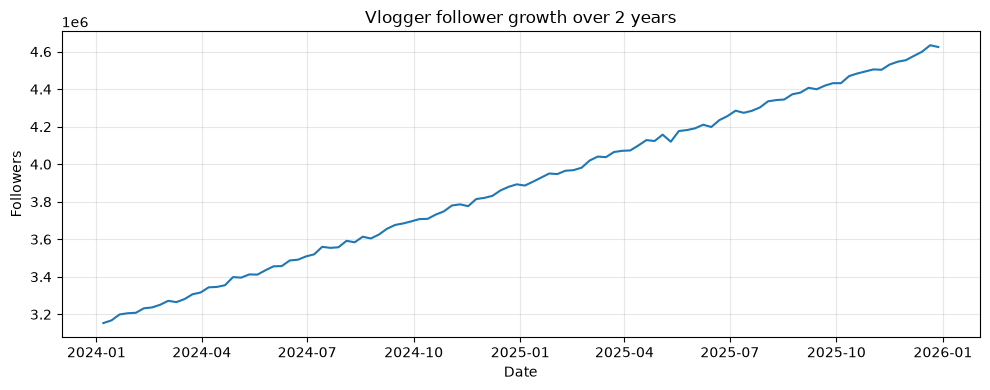

In [5]:
# ---- Total follower growth over the full 2 years, by client type ----
GROWTH_RANGES = {
    "chiropractor": (0.15, 0.25),
    "real_estate_agent": (0.15, 0.25),
    "aesthetician": (0.30, 0.50),
    "vlogger": (0.40, 0.70),
}

# ---- Fixed total growth rate per client, drawn once ----
CLIENT_GROWTH_RATE = {
    client: random.uniform(*rng) for client, rng in GROWTH_RANGES.items()
}

def followers_on_date(client_name, date):
    """Linear growth trend with small random noise layered on top, so the curve looks organic rather than a perfectly straight line."""
    base = CLIENT_FOLLOWERS[client_name]
    growth_rate = CLIENT_GROWTH_RATE[client_name]
    day_index = (date - START_DATE).days
    progress = day_index / (END_DATE - START_DATE).days  # 0.0 to 1.0
    trend_value = base * (1 + growth_rate * progress)
    noise = np.random.normal(loc=1.0, scale=0.003)  # global random state — fine here since only Cells 1-9 call this; Cells 10-12 need per-cell reproducibility and use their own local copies instead (see Cell 10)
    return int(trend_value * noise)

print("Total 2-year growth rate per client:")
for client, rate in CLIENT_GROWTH_RATE.items():
    start_f = CLIENT_FOLLOWERS[client]
    end_f = followers_on_date(client, END_DATE)
    print(f"  {client}: {rate:.1%} growth  ({start_f:,} -> {end_f:,})")

# ---- Visual check ----
sample_dates = pd.date_range(START_DATE, END_DATE, freq='W')
sample_followers = [followers_on_date("vlogger", d) for d in sample_dates]

plt.figure(figsize=(10, 4))
plt.plot(sample_dates, sample_followers)
plt.title("Vlogger follower growth over 2 years")
plt.xlabel("Date"); plt.ylabel("Followers"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Cell 5: Seasonal Event Multipliers

Defines each client's seasonal pattern as a month-by-month multiplier table (e.g. real estate agent gets +40% in June, -25% in January), plus the vlogger's one-time algorithm-change dip placed in a ~5-week window during Year 2 only, followed by a gradual ~2-week recovery rather than an instant snap-back.

Month-by-month anchor values are interpolated into a smooth day-by-day curve with `PchipInterpolator`, which stays rounded at the transitions without overshooting past the anchor values themselves (e.g. the aesthetician's Nov/Dec peak never exceeds its intended 1.55 max).

Plots the aesthetician (clean seasonal curve) and vlogger (seasonal curve + algorithm dip) multipliers across both years to confirm the shape before applying it to actual reach numbers.

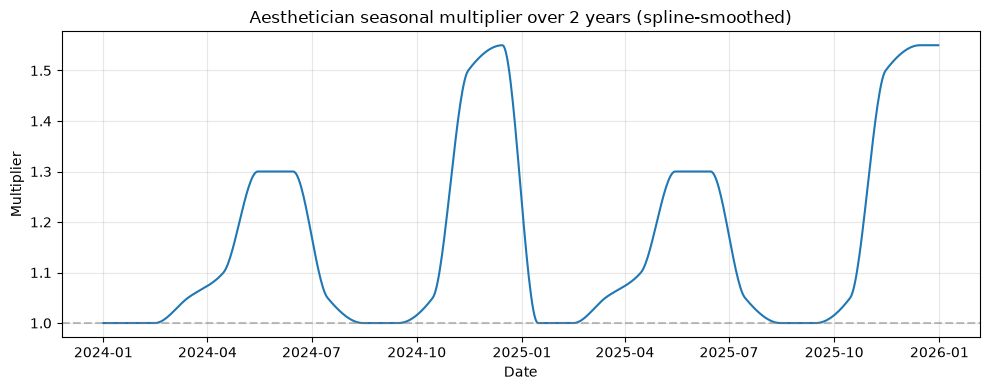

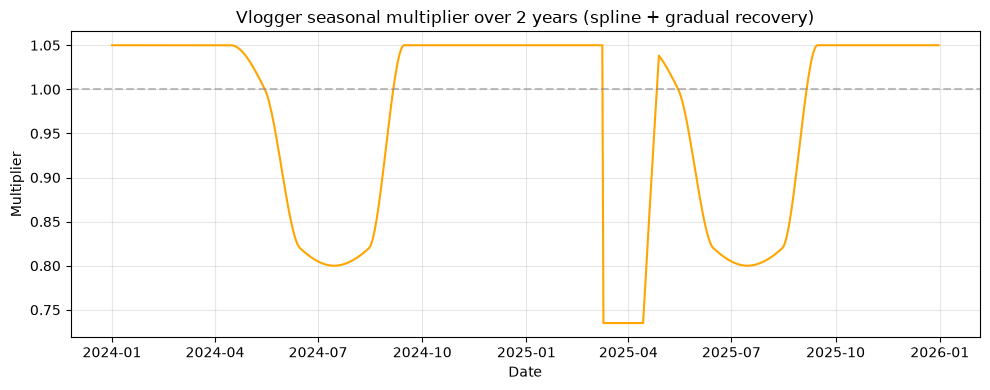

In [6]:
# ---- Month-by-month multipliers per client (1.0 = baseline, no change). Keys are month numbers 1-12, applied identically in both years ----
SEASONAL_MULTIPLIERS = {
    "real_estate_agent": {
        1: 0.75, 2: 0.75, 3: 1.35, 4: 1.40, 5: 1.45, 6: 1.50, 7: 1.45, 8: 1.35, 9: 1.10, 10: 1.10, 11: 0.85, 12: 0.75,
    },
    "chiropractor": {
        1: 1.40, 2: 1.05, 3: 1.00, 4: 1.15, 5: 1.20, 6: 1.10, 7: 1.10, 8: 1.10, 9: 1.15, 10: 1.20, 11: 0.85, 12: 0.85,
    },
    "aesthetician": {
        1: 1.00, 2: 1.00, 3: 1.05, 4: 1.10, 5: 1.30, 6: 1.30, 7: 1.05, 8: 1.00, 9: 1.00, 10: 1.05, 11: 1.50, 12: 1.55,
    },
    "vlogger": {
        1: 1.05, 2: 1.05, 3: 1.05, 4: 1.05, 5: 1.00, 6: 0.82, 7: 0.80, 8: 0.82, 9: 1.05, 10: 1.05, 11: 1.05, 12: 1.05,
    },
}

# ---- Vlogger algorithm-change dip — one-time event, Year 2 only, ~5 week window ----
ALGO_DIP_START = datetime(2025, 3, 10)   # arbitrary placement, adjustable
ALGO_DIP_END = ALGO_DIP_START + timedelta(weeks=5)
ALGO_DIP_MULTIPLIER = 0.70  # -30% during the dip window
ALGO_DIP_RECOVERY_WEEKS = 2  # gradual taper back to baseline after the dip

def build_seasonal_series(client_name):
    """Builds a smooth, day-by-day seasonal multiplier via PCHIP interpolation through each month's anchor value (at the 15th)."""
    anchor_days, anchor_values = [], []
    for year in (2024, 2025):
        for month in range(1, 13):
            anchor_date = datetime(year, month, 15)
            anchor_days.append((anchor_date - START_DATE).days)
            anchor_values.append(SEASONAL_MULTIPLIERS[client_name][month])

    total_days = (END_DATE - START_DATE).days
    anchor_days = [0] + anchor_days + [total_days]
    anchor_values = [anchor_values[0]] + anchor_values + [anchor_values[-1]]

    pchip = PchipInterpolator(anchor_days, anchor_values)
    all_day_indices = [(d - START_DATE).days for d in ALL_DATES]
    smooth_values = pchip(all_day_indices)
    return pd.Series(smooth_values, index=ALL_DATES)

# ---- Precompute the smooth seasonal curve for every client, once ----
SEASONAL_SERIES = {client: build_seasonal_series(client) for client in CLIENTS}

def seasonal_multiplier(client_name, date):
    """Smoothed seasonal multiplier, with the vlogger's algorithm dip: sudden onset, gradual recovery over ALGO_DIP_RECOVERY_WEEKS."""
    base_mult = SEASONAL_SERIES[client_name].loc[date]

    if client_name == "vlogger":
        recovery_end = ALGO_DIP_END + timedelta(weeks=ALGO_DIP_RECOVERY_WEEKS)
        if ALGO_DIP_START <= date <= ALGO_DIP_END:
            return base_mult * ALGO_DIP_MULTIPLIER
        elif ALGO_DIP_END < date <= recovery_end:
            days_into_recovery = (date - ALGO_DIP_END).days
            recovery_progress = days_into_recovery / (ALGO_DIP_RECOVERY_WEEKS * 7)
            taper = ALGO_DIP_MULTIPLIER + (1 - ALGO_DIP_MULTIPLIER) * recovery_progress
            return base_mult * taper

    return base_mult

# ---- Visual check ----
sample_dates = pd.date_range(START_DATE, END_DATE, freq='D')

plt.figure(figsize=(10, 4))
plt.plot(sample_dates, [seasonal_multiplier("aesthetician", d) for d in sample_dates])
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.title("Aesthetician seasonal multiplier over 2 years (spline-smoothed)")
plt.xlabel("Date"); plt.ylabel("Multiplier"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 4))
plt.plot(sample_dates, [seasonal_multiplier("vlogger", d) for d in sample_dates], color='orange')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.title("Vlogger seasonal multiplier over 2 years (spline + gradual recovery)")
plt.xlabel("Date"); plt.ylabel("Multiplier"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Cell 6: Combine Growth Trend + Seasonality into the Final Per-Post Dataset

Takes the baseline per-post data from Cell 3 (generated against a fixed follower count, no time trend or seasonality) and layers in:

1. **Growth trend (Cell 4)** — scales reach by how much bigger/smaller the account actually was on that specific post's date vs. the fixed baseline count used to generate it.
2. **Seasonality (Cell 5)** — scales reach up/down by time-of-year demand, plus the vlogger's algorithm dip.

`engagement_rate` is left untouched — it represents audience response quality, not reach size — so `total_engagements` and the likes/comments/shares/saves split are recalculated from the new reach using that same rate and the same 70/12/10/remainder proportions as Cell 2.

Produces `final_df` — the real dataset, before funnel/conversion layers and anomaly injection get added in later cells.

In [7]:
def apply_growth_and_seasonality(row):
    """Applies growth trend + seasonal multiplier to one baseline post row, recalculating reach and all downstream engagement figures from it."""
    client = row["client"]
    date = row["date"]

    # ---- Growth: how much bigger/smaller the account was on this date vs. the fixed baseline follower count the row was generated with ----
    baseline_followers = CLIENT_FOLLOWERS[client]
    actual_followers = followers_on_date(client, date)
    growth_factor = actual_followers / baseline_followers

    # ---- Seasonality: time-of-year curve + (vlogger-only) algorithm dip ----
    season_mult = seasonal_multiplier(client, date)

    combined_mult = growth_factor * season_mult
    new_reach = max(1, int(round(row["reach"] * combined_mult)))

    # ---- Re-derive engagement figures from the new reach — same rate, same split as Cell 2 ----
    engagement_rate = row["engagement_rate"]
    total_engagements = int(new_reach * engagement_rate)
    likes = int(total_engagements * 0.70)
    comments = int(total_engagements * 0.12)
    shares = int(total_engagements * 0.10)
    saves = total_engagements - likes - comments - shares

    return pd.Series({
        "followers": actual_followers,
        "reach": new_reach,
        "likes": likes,
        "comments": comments,
        "shares": shares,
        "saves": saves,
        "total_engagements": total_engagements,
        "engagement_rate": engagement_rate,
    })

# ---- Apply row-by-row — baseline_df is ~2,943 rows, small enough for .apply ----
updated_cols = baseline_df.apply(apply_growth_and_seasonality, axis=1)

final_df = baseline_df[["date", "client", "platform"]].copy()
final_df = pd.concat([final_df, updated_cols], axis=1)
final_df = final_df[["date", "client", "platform", "followers", "reach",
                      "likes", "comments", "shares", "saves",
                      "total_engagements", "engagement_rate"]]
count_cols = ["followers", "reach", "likes", "comments", "shares", "saves", "total_engagements"]
final_df[count_cols] = final_df[count_cols].round().astype(int)

print(f"final_df shape: {final_df.shape}")
final_df.head(10)

final_df shape: (2943, 11)


,date,client,platform,followers,reach,likes,comments,shares,saves,total_engagements,engagement_rate
0,2024-01-07,chiropractor,instagram,33263,7949,270,46,38,32,386,0.0486
1,2024-01-11,chiropractor,instagram,33260,8595,303,51,43,36,433,0.0504
2,2024-01-16,chiropractor,instagram,33114,13773,577,99,82,67,825,0.0599
3,2024-01-18,chiropractor,instagram,33318,5400,235,40,33,28,336,0.0624
4,2024-01-25,chiropractor,instagram,33379,11884,288,49,41,34,412,0.0347
5,2024-01-28,chiropractor,instagram,33643,12063,373,63,53,44,533,0.0442
6,2024-02-01,chiropractor,instagram,33407,13225,581,99,83,67,830,0.0628
7,2024-02-03,chiropractor,instagram,33472,7241,373,63,53,44,533,0.0737
8,2024-02-07,chiropractor,instagram,33468,5077,210,36,30,24,300,0.0591
9,2024-02-14,chiropractor,instagram,33407,12037,399,68,57,47,571,0.0475


**Integrity checks on the merged dataset** — confirms the engagement split and reach-vs-followers relationship still hold after growth + seasonality are layered in, and plots baseline vs. final reach for one client-platform pair so both effects are visible together.

Likes+comments+shares+saves == total_engagements for all rows: True
Rows where reach exceeds followers (should be 0): 0


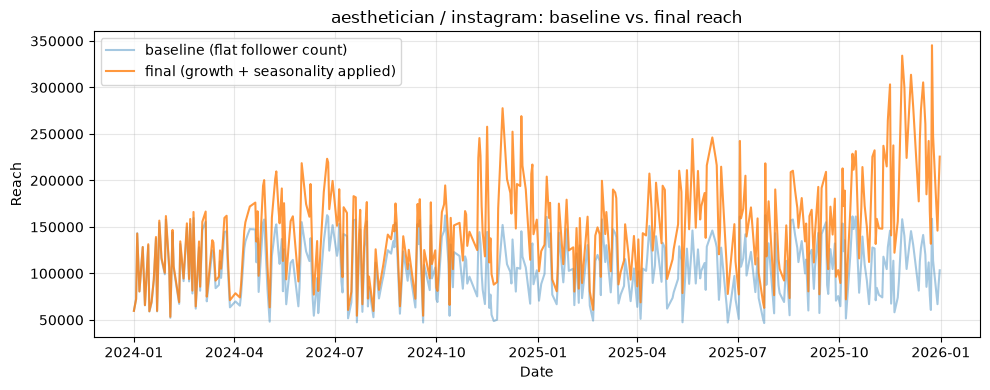

client             year
aesthetician       2024     49591030
                   2025     59105933
chiropractor       2024      1424762
                   2025      1469476
real_estate_agent  2024       597634
                   2025       705063
vlogger            2024    611343182
                   2025    714990865
Name: reach, dtype: int64


In [8]:
# ---- Integrity check ----
split_ok = (final_df["likes"] + final_df["comments"] + final_df["shares"]
            + final_df["saves"] == final_df["total_engagements"]).all()
overflow = (final_df["reach"] > final_df["followers"]).sum()
print(f"Likes+comments+shares+saves == total_engagements for all rows: {split_ok}")
print(f"Rows where reach exceeds followers (should be 0): {overflow}")

# ---- Visual check: baseline vs. final reach for one client-platform pair, so growth + seasonality effects are both visible together ----
check_client, check_platform = "aesthetician", "instagram"
mask = (baseline_df["client"] == check_client) & (baseline_df["platform"] == check_platform)

plt.figure(figsize=(10, 4))
plt.plot(baseline_df.loc[mask, "date"], baseline_df.loc[mask, "reach"],
         alpha=0.4, label="baseline (flat follower count)")
plt.plot(final_df.loc[mask, "date"], final_df.loc[mask, "reach"],
         alpha=0.8, label="final (growth + seasonality applied)")
plt.title(f"{check_client} / {check_platform}: baseline vs. final reach")
plt.xlabel("Date"); plt.ylabel("Reach"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- Reach by year: should rise 2024 -> 2025 per client (growth), and each client's split should echo its seasonal shape ----
final_df["year"] = final_df["date"].dt.year
print(final_df.groupby(["client", "year"])["reach"].sum())
final_df.drop(columns="year", inplace=True)

## Cell 7: Aesthetician Store — Baseline (Non-Social) Daily Traffic

Builds the store's day-by-day baseline Sessions — the Direct/Search/Other visitors who'd show up regardless of that day's social activity.

Reuses the aesthetician's existing seasonal curve from Cell 5 (same business, same demand pattern), applies an independent store-specific growth rate, adds daily noise, and layers a distinct Black Friday/Cyber Monday spike on top of the smooth Nov/Dec seasonal rise — same "sharp event on a smooth curve" device already used for the vlogger's algorithm dip.

Social-driven sessions are NOT included yet — that's Cell 8. This is just the traffic the store would get with zero social presence.

Store baseline sessions (Jan 2024): 626
Store growth rate (2yr): 32.4%
BFCM multiplier: 2.34x

Baseline sessions by year:
         sum        mean   max
year                          
2024  293319  801.418033  2765
2025  338321  926.906849  3162


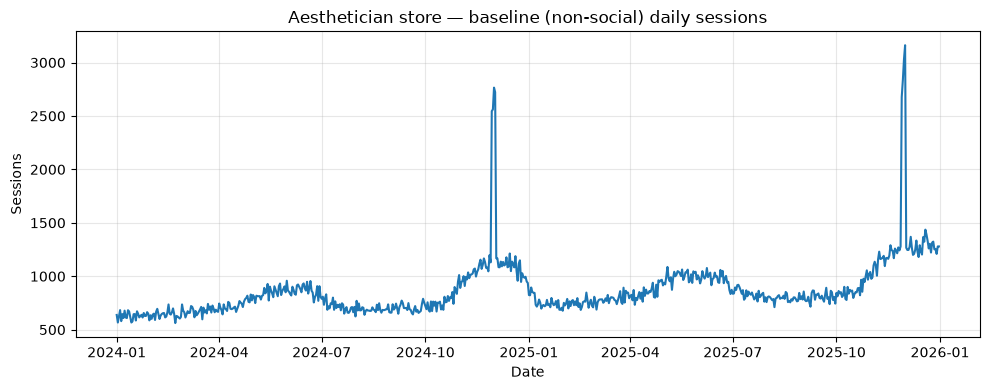

In [9]:
# Dedicated generators for this cell — seed 107. Immune to how many times this or any other cell gets re-run; only this cell's own code changes its output.
cell7_rng = random.Random(107)
cell7_np_rng = np.random.default_rng(107)

# ---- Store growth config ----
STORE_BASE_SESSIONS = cell7_rng.randint(500, 900)
STORE_GROWTH_RATE = cell7_rng.uniform(0.20, 0.40)

# ---- BFCM (Black Friday/Cyber Monday) windows ----
BFCM_WINDOWS = [
    (datetime(2024, 11, 29), datetime(2024, 12, 2)),
    (datetime(2025, 11, 28), datetime(2025, 12, 1)),
]
BFCM_MULTIPLIER = cell7_rng.uniform(1.8, 2.5)

def store_growth_factor(date):
    day_index = (date - START_DATE).days
    progress = day_index / (END_DATE - START_DATE).days
    return 1 + STORE_GROWTH_RATE * progress

def is_bfcm(date):
    return any(start <= date <= end for start, end in BFCM_WINDOWS)

def baseline_sessions_on_date(date):
    growth = store_growth_factor(date)
    season = seasonal_multiplier("aesthetician", date)
    noise = cell7_np_rng.normal(loc=1.0, scale=0.05)
    sessions = STORE_BASE_SESSIONS * growth * season * noise
    if is_bfcm(date):
        sessions *= BFCM_MULTIPLIER
    return max(0, int(round(sessions)))

ga_baseline_df = pd.DataFrame({"date": ALL_DATES})
ga_baseline_df["baseline_sessions"] = ga_baseline_df["date"].apply(baseline_sessions_on_date)

print(f"Store baseline sessions (Jan 2024): {STORE_BASE_SESSIONS}")
print(f"Store growth rate (2yr): {STORE_GROWTH_RATE:.1%}")
print(f"BFCM multiplier: {BFCM_MULTIPLIER:.2f}x")
print(f"\nBaseline sessions by year:")
ga_baseline_df["year"] = ga_baseline_df["date"].dt.year
print(ga_baseline_df.groupby("year")["baseline_sessions"].agg(["sum", "mean", "max"]))
ga_baseline_df.drop(columns="year", inplace=True)

# ---- Visual check ----
plt.figure(figsize=(10, 4))
plt.plot(ga_baseline_df["date"], ga_baseline_df["baseline_sessions"])
plt.title("Aesthetician store — baseline (non-social) daily sessions")
plt.xlabel("Date"); plt.ylabel("Sessions"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Cell 8: Social-Driven Sessions + Traffic Source Split

1. **Social-driven sessions** — each day's combined Instagram+TikTok `total_engagements` (from `final_df`, not raw `reach` — the people who actually interacted, not everyone who scrolled past) converts to store visits at a random 3%-9% rate, with a decay tail (day of post = full effect, +1 day ≈ half, +2 days ≈ quarter).
2. **Traffic source split** — `baseline_sessions` splits into Direct/Search/Other (~30/50/20%, daily noise); Social sessions come directly from step 1. All four sum exactly to `total_sessions`.

Social click-through rate (of engagements): 1.83%
Direct+Search+Other == baseline_sessions for all rows: True
All four sources sum to total_sessions for all rows: True

Social sessions by year:
         sum        mean
year                    
2024  112352  306.972678
2025  128206  351.249315

Baseline (non-social) sessions by year, for comparison:
         sum        mean
year                    
2024  293319  801.418033
2025  338321  926.906849


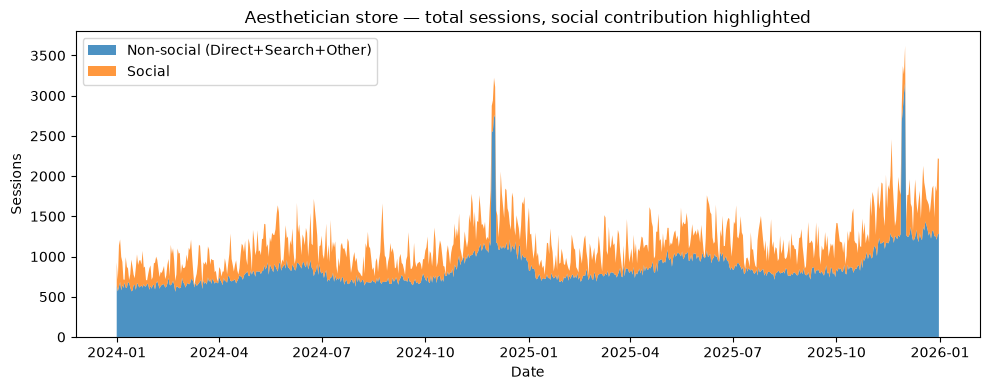

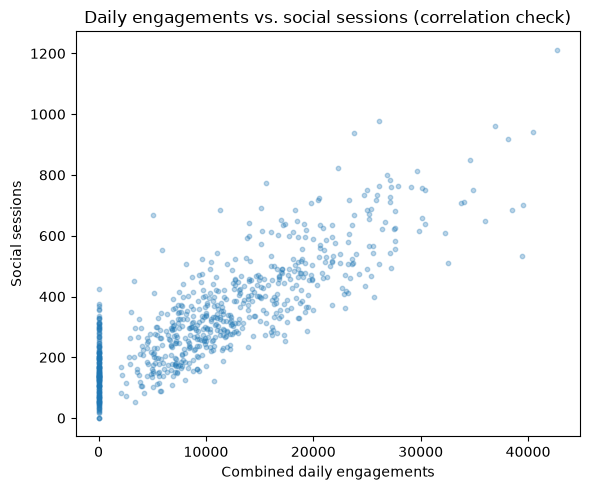

In [10]:
# Dedicated generators for this cell — seed 108. Immune to how many times this or any other cell gets re-run; only this cell's own code changes its output.
cell8_rng = random.Random(108)
cell8_np_rng = np.random.default_rng(108)

# ---- Social-driven sessions (engagement-based, with decay tail) ----
daily_engagements = (
    final_df[final_df["client"] == "aesthetician"]
    .groupby("date")["total_engagements"].sum()
    .reindex(ALL_DATES, fill_value=0)
)

SOCIAL_CTR_RATE = cell8_rng.uniform(0.015, 0.04)
daily_noise = np.clip(cell8_np_rng.normal(1.0, 0.15, size=len(ALL_DATES)), 0, None)

immediate_sessions = pd.Series(
    daily_engagements.values * SOCIAL_CTR_RATE * daily_noise, index=ALL_DATES
)
social_sessions = (
    immediate_sessions
    + 0.5 * immediate_sessions.shift(1, fill_value=0)
    + 0.25 * immediate_sessions.shift(2, fill_value=0)
).round().astype(int)

# ---- Traffic source split ----
TRAFFIC_SPLIT_TARGET = np.array([0.30, 0.50, 0.20])
noise = cell8_np_rng.normal(0, 0.04, size=(len(ALL_DATES), 3))
raw_weights = np.clip(TRAFFIC_SPLIT_TARGET + noise, 0.05, None)
proportions = raw_weights / raw_weights.sum(axis=1, keepdims=True)

baseline_vals = ga_baseline_df["baseline_sessions"].values
direct = np.floor(proportions[:, 0] * baseline_vals).astype(int)
search = np.floor(proportions[:, 1] * baseline_vals).astype(int)
other = baseline_vals - direct - search

ga_df = ga_baseline_df.copy()
ga_df["social_sessions"] = social_sessions.values
ga_df["direct_sessions"] = direct
ga_df["search_sessions"] = search
ga_df["other_sessions"] = other
ga_df["total_sessions"] = ga_df["baseline_sessions"] + ga_df["social_sessions"]

print(f"Social click-through rate (of engagements): {SOCIAL_CTR_RATE:.2%}")

# ---- Integrity checks ----
split_ok = (ga_df["direct_sessions"] + ga_df["search_sessions"] + ga_df["other_sessions"]
            == ga_df["baseline_sessions"]).all()
total_ok = (ga_df["direct_sessions"] + ga_df["search_sessions"] + ga_df["other_sessions"]
            + ga_df["social_sessions"] == ga_df["total_sessions"]).all()
print(f"Direct+Search+Other == baseline_sessions for all rows: {split_ok}")
print(f"All four sources sum to total_sessions for all rows: {total_ok}")

ga_df["year"] = ga_df["date"].dt.year
print("\nSocial sessions by year:")
print(ga_df.groupby("year")["social_sessions"].agg(["sum", "mean"]))
print("\nBaseline (non-social) sessions by year, for comparison:")
print(ga_df.groupby("year")["baseline_sessions"].agg(["sum", "mean"]))
ga_df.drop(columns="year", inplace=True)

# ---- Visual check ----
plt.figure(figsize=(10, 4))
plt.stackplot(ga_df["date"], ga_df["baseline_sessions"], ga_df["social_sessions"],
              labels=["Non-social (Direct+Search+Other)", "Social"], alpha=0.8)
plt.title("Aesthetician store — total sessions, social contribution highlighted")
plt.xlabel("Date"); plt.ylabel("Sessions"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(daily_engagements.values, ga_df["social_sessions"], alpha=0.3, s=10)
plt.title("Daily engagements vs. social sessions (correlation check)")
plt.xlabel("Combined daily engagements"); plt.ylabel("Social sessions")
plt.tight_layout(); plt.show()

## Cell 9: New vs. Returning Split, Conversion Rates, Orders & Revenue

Three pieces, building on Cell 8's `ga_df`:

1. **New vs. Returning split** (descriptive only — doesn't feed its own conversion rate, to avoid stacking a third multiplier on top of the two below). Baseline (non-social) sessions: Returning share rises slowly from ~30% to ~55% over the 2 years — an established business building a loyal base. Social sessions skew toward New (discovery), with a smaller Returning share representing existing customers coming back for a product they saw posted.
2. **Conversion rates** — non-social (1.0-2.5%) and social-sourced (2.5-5.0%) stay separate. Both get a dampened seasonal lift (~40% the strength of the traffic multiplier). Social conversion additionally scales with that day's actual engagement rate, relative to this dataset's own average (self-calibrating, not a hardcoded assumption). Hard caps: 4% non-social, 8% social.
3. **Orders & Revenue** — Orders from each session stream at its own conversion rate, summed. Revenue = Orders x AOV, AOV drawn per-store at $55-$95 (Jan 2024 level) with ~8% drift over the 2 years.

BFCM gets its session spike from Cell 7 already — no extra BFCM-specific conversion boost is added on top of the standard seasonal lift, keeping this to the two multiplier layers described above.

AOV base (Jan 2024): $73.37
Social Returning share: 22.8%
Dataset avg engagement rate (self-calibration baseline): 7.02%
New + Returning sessions == total_sessions for all rows: True
Non-social conversion rate range: 1.00% - 3.04% (cap 4%)
Social conversion rate range: 1.93% - 7.31% (cap 8%)
Non-social: 0 of 731 days would have exceeded the 4% cap pre-clip (max raw: 3.04%)
Social: 0 of 731 days would have exceeded the 8% cap pre-clip (max raw: 7.31%)

Orders & Revenue by year:
     orders               revenue             
        sum       mean        sum         mean
year                                          
2024  10264  28.043716  762955.32  2084.577377
2025  11710  32.082192  919414.99  2518.945178

Returning share of sessions by year:
year
2024    0.328020
2025    0.421388
dtype: float64

BFCM window orders/revenue:
          date  orders  revenue
333 2024-11-29      78  5665.14
334 2024-11-30      65  3807.70
335 2024-12-01      94  6752.96
336 2024-12-02      75  4462.50
69

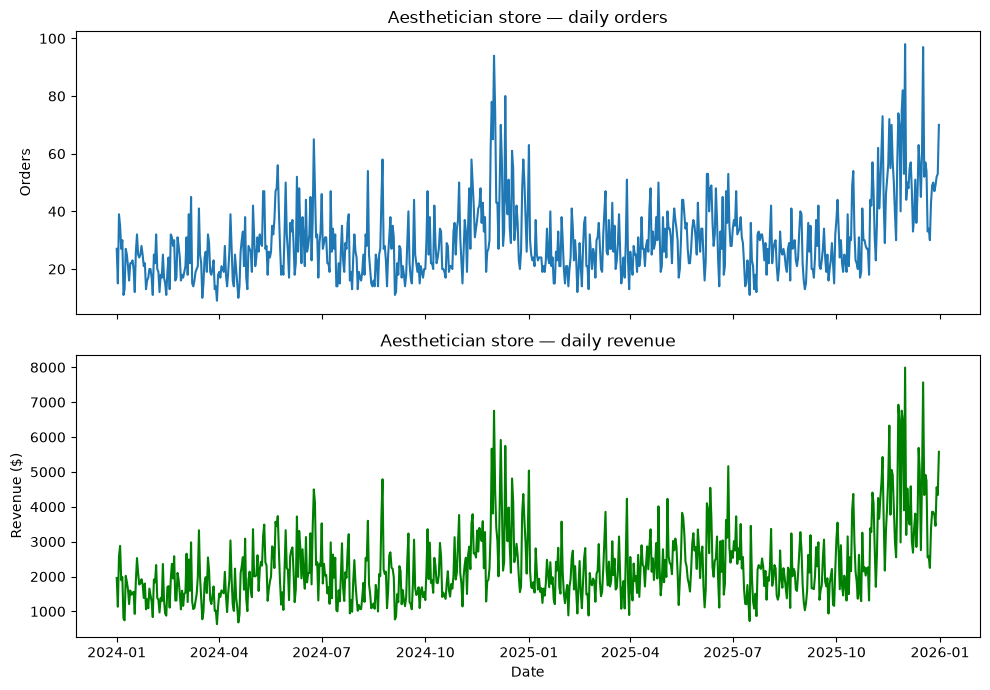

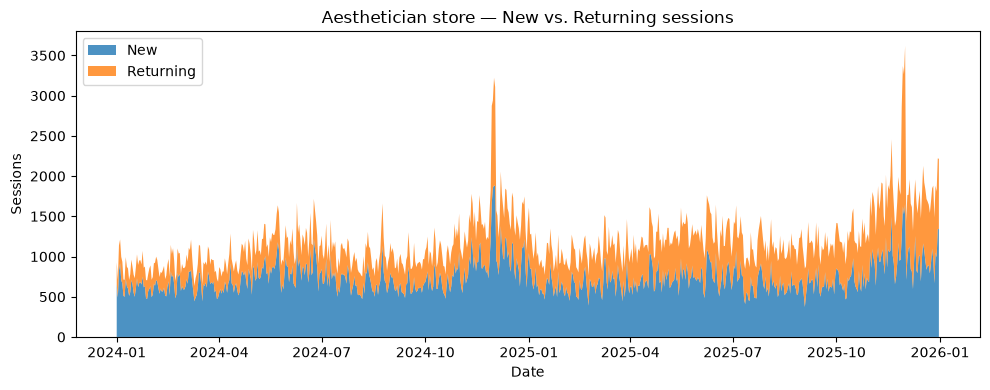

In [11]:
# Dedicated generators for this cell — seed 109. Immune to how many times this or any other cell gets re-run; only this cell's own code changes its output.
cell9_rng = random.Random(109)
cell9_np_rng = np.random.default_rng(109)

# ---- New vs. Returning split ----
def returning_share_baseline(date):
    progress = (date - START_DATE).days / (END_DATE - START_DATE).days
    return 0.30 + 0.25 * progress

baseline_returning_share = np.array([returning_share_baseline(d) for d in ALL_DATES])
baseline_returning_noise = np.clip(cell9_np_rng.normal(1.0, 0.08, len(ALL_DATES)), 0.5, 1.5)
baseline_returning_share = np.clip(baseline_returning_share * baseline_returning_noise, 0.1, 0.9)

baseline_returning = np.round(ga_df["baseline_sessions"].values * baseline_returning_share).astype(int)
baseline_new = ga_df["baseline_sessions"].values - baseline_returning

SOCIAL_RETURNING_SHARE = cell9_rng.uniform(0.20, 0.30)
social_returning_noise = np.clip(cell9_np_rng.normal(1.0, 0.08, len(ALL_DATES)), 0.5, 1.5)
social_returning_share = np.clip(SOCIAL_RETURNING_SHARE * social_returning_noise, 0.05, 0.6)

social_returning = np.round(ga_df["social_sessions"].values * social_returning_share).astype(int)
social_new = ga_df["social_sessions"].values - social_returning

ga_df["new_sessions"] = baseline_new + social_new
ga_df["returning_sessions"] = baseline_returning + social_returning

# ---- Conversion rates ----
daily_reach = (
    final_df[final_df["client"] == "aesthetician"]
    .groupby("date")["reach"].sum()
    .reindex(ALL_DATES, fill_value=0)
)

seasonal_mult_series = pd.Series(
    [seasonal_multiplier("aesthetician", d) for d in ALL_DATES], index=ALL_DATES
)
seasonal_lift = (seasonal_mult_series - 1) * 0.4

NON_SOCIAL_BASE_RATE = cell9_np_rng.uniform(0.010, 0.025, len(ALL_DATES))
SOCIAL_BASE_RATE = cell9_np_rng.uniform(0.025, 0.050, len(ALL_DATES))

daily_engagement_rate = (daily_engagements / daily_reach).replace([np.inf, -np.inf], np.nan)
avg_engagement_rate = daily_engagement_rate.mean()
engagement_boost = 1 + 0.5 * (daily_engagement_rate / avg_engagement_rate - 1)
engagement_boost = engagement_boost.fillna(1.0).clip(0.7, 1.5)

non_social_rate_raw = NON_SOCIAL_BASE_RATE * (1 + seasonal_lift.values)
social_rate_raw = SOCIAL_BASE_RATE * (1 + seasonal_lift.values) * engagement_boost.values

non_social_rate = np.clip(non_social_rate_raw, 0, 0.04)
social_rate = np.clip(social_rate_raw, 0, 0.08)

ga_df["non_social_conversion_rate"] = non_social_rate
ga_df["social_conversion_rate"] = social_rate

# ---- Orders & Revenue ----
orders_non_social = ga_df["baseline_sessions"] * ga_df["non_social_conversion_rate"]
orders_social = ga_df["social_sessions"] * ga_df["social_conversion_rate"]
ga_df["orders"] = (orders_non_social + orders_social).round().astype(int)

AOV_BASE = cell9_rng.uniform(55, 95)
AOV_GROWTH = 0.08
aov_progress = np.array([(d - START_DATE).days / (END_DATE - START_DATE).days for d in ALL_DATES])
aov_noise = np.clip(cell9_np_rng.normal(1.0, 0.10, len(ALL_DATES)), 0.5, None)
aov = AOV_BASE * (1 + AOV_GROWTH * aov_progress) * aov_noise

ga_df["aov"] = aov.round(2)
ga_df["revenue"] = (ga_df["orders"] * ga_df["aov"]).round(2)

# ---- Shared schema: primary outcome ----
ga_df["primary_outcome_count"] = ga_df["orders"]
ga_df["primary_outcome_label"] = "Orders"

print(f"AOV base (Jan 2024): ${AOV_BASE:.2f}")
print(f"Social Returning share: {SOCIAL_RETURNING_SHARE:.1%}")
print(f"Dataset avg engagement rate (self-calibration baseline): {avg_engagement_rate:.2%}")

# ---- Integrity checks ----
new_ret_ok = (ga_df["new_sessions"] + ga_df["returning_sessions"] == ga_df["total_sessions"]).all()
print(f"New + Returning sessions == total_sessions for all rows: {new_ret_ok}")
print(f"Non-social conversion rate range: {ga_df['non_social_conversion_rate'].min():.2%} - "
      f"{ga_df['non_social_conversion_rate'].max():.2%} (cap 4%)")
print(f"Social conversion rate range: {ga_df['social_conversion_rate'].min():.2%} - "
      f"{ga_df['social_conversion_rate'].max():.2%} (cap 8%)")

non_social_hit_cap = (non_social_rate_raw > 0.04).sum()
social_hit_cap = (social_rate_raw > 0.08).sum()
print(f"Non-social: {non_social_hit_cap} of {len(non_social_rate_raw)} days would have "
      f"exceeded the 4% cap pre-clip (max raw: {non_social_rate_raw.max():.2%})")
print(f"Social: {social_hit_cap} of {len(social_rate_raw)} days would have "
      f"exceeded the 8% cap pre-clip (max raw: {social_rate_raw.max():.2%})")

ga_df["year"] = ga_df["date"].dt.year
print("\nOrders & Revenue by year:")
print(ga_df.groupby("year")[["orders", "revenue"]].agg(["sum", "mean"]))
print("\nReturning share of sessions by year:")
print(ga_df.groupby("year")["returning_sessions"].sum() / ga_df.groupby("year")["total_sessions"].sum())
print("\nBFCM window orders/revenue:")
print(ga_df[ga_df["date"].apply(is_bfcm)][["date", "orders", "revenue"]])
ga_df.drop(columns="year", inplace=True)

# ---- Visual check ----
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(ga_df["date"], ga_df["orders"])
axes[0].set_title("Aesthetician store — daily orders")
axes[0].set_ylabel("Orders")
axes[1].plot(ga_df["date"], ga_df["revenue"], color="green")
axes[1].set_title("Aesthetician store — daily revenue")
axes[1].set_ylabel("Revenue ($)")
axes[1].set_xlabel("Date")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 4))
plt.stackplot(ga_df["date"], ga_df["new_sessions"], ga_df["returning_sessions"],
              labels=["New", "Returning"], alpha=0.8)
plt.title("Aesthetician store — New vs. Returning sessions")
plt.xlabel("Date"); plt.ylabel("Sessions"); plt.legend(); plt.tight_layout(); plt.show()

## Cell 10: Chiropractor — Booking Inquiries, Show-up Rate, New vs. Returning, Primary Outcome

Lightweight conversion layer for the chiropractor, reusing the existing growth trend (`followers_on_date`) and seasonal multiplier (`seasonal_multiplier`) rather than building separate baseline/social-split cells like the aesthetician's full funnel.

1. **Booking inquiries** — a weekly base (8-20/week) converted to a daily rate, scaled by the chiropractor's own growth trend and seasonal curve (Jan fitness spike, spring/fall marathon bumps, summer injury upticks, winter lull), plus a modest self-calibrating engagement boost (lighter than the aesthetician's, since this layer is meant to stay lightweight).
2. **Show-up rate** — 75-90% base, realistic for a local healthcare-adjacent service, with a seasonal dip in Nov-Dec (holiday travel/schedule chaos causing more no-shows on already-booked appointments).
3. **New vs. Returning inquiry split** — returning share starts at 40% and grows to 55% over the 2 years. Deliberately higher-starting than the aesthetician's 30%-to-55% e-commerce split: chiropractic returning visits are usually within one active multi-session treatment plan (weeks, not months apart), a structurally tighter repeat pattern than repeat product purchases.
4. **`primary_outcome_count` / `primary_outcome_label`** — set to completed visits (booking inquiries × show-up rate), not raw inquiries, matching the aesthetician's Orders as the bottom-of-funnel, revenue-relevant event. Shared across all four clients so one dashboard template can render "this month's {primary_outcome_label}: {primary_outcome_count}" with zero client-specific branching.

Booking base (weekly): 19.2
Show-up rate base: 80.8%
New + Returning == booking_inquiries for all rows: True
Completed visits never exceeds booking inquiries: True

Booking inquiries & completed visits by year:
     booking_inquiries           completed_visits          
                   sum      mean              sum      mean
year                                                       
2024              1102  3.010929              852  2.327869
2025              1192  3.265753              914  2.504110

Returning share of inquiries by year:
year
2024    0.419238
2025    0.512584
dtype: float64

Show-up rate by year:
year
2024    0.792900
2025    0.792883
Name: show_up_rate, dtype: float64


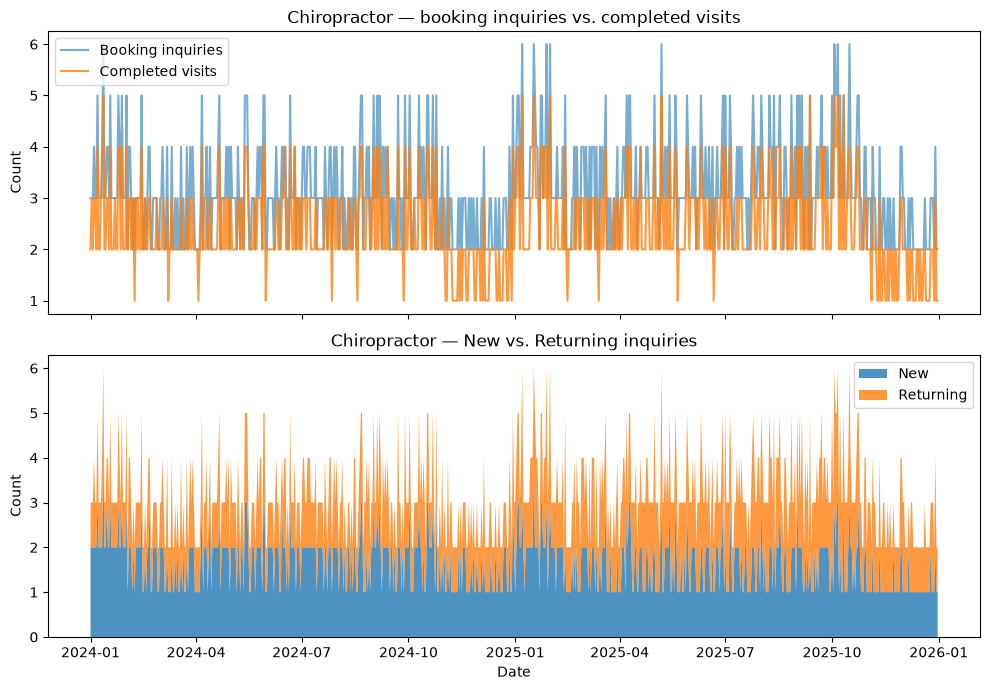

In [12]:
# Dedicated generators for this cell — seed 110. Immune to how many times this or any other cell gets re-run; only this cell's own code changes its output.
cell10_rng = random.Random(110)
cell10_np_rng = np.random.default_rng(110)

# ---- Booking inquiries ----
BOOKING_BASE_WEEKLY = cell10_rng.uniform(8, 20)
BOOKING_BASE_DAILY = BOOKING_BASE_WEEKLY / 7

def cell10_followers_on_date(date):
    """Local copy of Cell 4's growth-trend formula, using this cell's own dedicated generator instead of the shared global state — keeps this cell fully reproducible on its own re-runs."""
    base = CLIENT_FOLLOWERS["chiropractor"]
    growth_rate = CLIENT_GROWTH_RATE["chiropractor"]
    progress = (date - START_DATE).days / (END_DATE - START_DATE).days
    trend_value = base * (1 + growth_rate * progress)
    noise = cell10_np_rng.normal(loc=1.0, scale=0.003)
    return int(trend_value * noise)

def chiro_growth_factor(date):
    baseline_followers = CLIENT_FOLLOWERS["chiropractor"]
    actual_followers = cell10_followers_on_date(date)
    return actual_followers / baseline_followers

daily_engagements_chiro = (
    final_df[final_df["client"] == "chiropractor"]
    .groupby("date")["total_engagements"].sum()
    .reindex(ALL_DATES, fill_value=0)
)
avg_engagement_chiro = daily_engagements_chiro.mean()
# Self-calibrating boost, same spirit as Cell 9's aesthetician engagement_boost, but lighter (0.3 vs 0.5) — this layer is meant to stay lightweight
engagement_boost_chiro = 1 + 0.3 * (daily_engagements_chiro / avg_engagement_chiro - 1)
engagement_boost_chiro = engagement_boost_chiro.fillna(1.0).clip(0.8, 1.3)

def booking_inquiries_on_date(date):
    growth = chiro_growth_factor(date)
    season = seasonal_multiplier("chiropractor", date)
    boost = engagement_boost_chiro.loc[date]
    noise = cell10_np_rng.normal(loc=1.0, scale=0.12)
    inquiries = BOOKING_BASE_DAILY * growth * season * boost * noise
    return max(0, int(round(inquiries)))

chiro_df = pd.DataFrame({"date": ALL_DATES})
chiro_df["booking_inquiries"] = chiro_df["date"].apply(booking_inquiries_on_date)

# ---- Show-up rate ----
SHOW_UP_RATE_BASE = cell10_rng.uniform(0.75, 0.90)

def show_up_rate_on_date(date):
    rate = SHOW_UP_RATE_BASE
    if date.month in (11, 12):  # holiday travel/schedule chaos -> more no-shows
        rate *= 0.90
    noise = cell10_np_rng.normal(loc=1.0, scale=0.05)
    return float(np.clip(rate * noise, 0.5, 0.98))

chiro_df["show_up_rate"] = chiro_df["date"].apply(show_up_rate_on_date)
chiro_df["completed_visits"] = np.round(
    chiro_df["booking_inquiries"] * chiro_df["show_up_rate"]
).astype(int)

# ---- New vs. Returning inquiry split ----
def returning_share_baseline_chiro(date):
    progress = (date - START_DATE).days / (END_DATE - START_DATE).days
    return 0.40 + 0.15 * progress  # 40% -> 55% returning over 2 years (multi-session treatment plans)

returning_share_chiro = np.array([returning_share_baseline_chiro(d) for d in ALL_DATES])
returning_noise_chiro = np.clip(cell10_np_rng.normal(1.0, 0.08, len(ALL_DATES)), 0.5, 1.5)
returning_share_chiro = np.clip(returning_share_chiro * returning_noise_chiro, 0.15, 0.85)

chiro_df["returning_inquiries"] = np.round(
    chiro_df["booking_inquiries"].values * returning_share_chiro
).astype(int)
chiro_df["new_inquiries"] = chiro_df["booking_inquiries"] - chiro_df["returning_inquiries"]

# ---- Shared schema: primary outcome ----
chiro_df["primary_outcome_count"] = chiro_df["completed_visits"]
chiro_df["primary_outcome_label"] = "Completed Visits"

# ---- Integrity checks ----
split_ok_chiro = (chiro_df["new_inquiries"] + chiro_df["returning_inquiries"]
                   == chiro_df["booking_inquiries"]).all()
visits_le_inquiries = (chiro_df["completed_visits"] <= chiro_df["booking_inquiries"]).all()

print(f"Booking base (weekly): {BOOKING_BASE_WEEKLY:.1f}")
print(f"Show-up rate base: {SHOW_UP_RATE_BASE:.1%}")
print(f"New + Returning == booking_inquiries for all rows: {split_ok_chiro}")
print(f"Completed visits never exceeds booking inquiries: {visits_le_inquiries}")

chiro_df["year"] = chiro_df["date"].dt.year
print("\nBooking inquiries & completed visits by year:")
print(chiro_df.groupby("year")[["booking_inquiries", "completed_visits"]].agg(["sum", "mean"]))
print("\nReturning share of inquiries by year:")
print(chiro_df.groupby("year")["returning_inquiries"].sum()
      / chiro_df.groupby("year")["booking_inquiries"].sum())
print("\nShow-up rate by year:")
print(chiro_df.groupby("year")["show_up_rate"].mean())
chiro_df.drop(columns="year", inplace=True)

# ---- Visual check ----
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(chiro_df["date"], chiro_df["booking_inquiries"], alpha=0.6, label="Booking inquiries")
axes[0].plot(chiro_df["date"], chiro_df["completed_visits"], alpha=0.8, label="Completed visits")
axes[0].set_title("Chiropractor — booking inquiries vs. completed visits")
axes[0].set_ylabel("Count"); axes[0].legend()
axes[1].stackplot(chiro_df["date"], chiro_df["new_inquiries"], chiro_df["returning_inquiries"],
                   labels=["New", "Returning"], alpha=0.8)
axes[1].set_title("Chiropractor — New vs. Returning inquiries")
axes[1].set_ylabel("Count"); axes[1].set_xlabel("Date"); axes[1].legend()
plt.tight_layout(); plt.show()

## Cell 11: Real Estate Agent — Inquiries, Showings, Closed Deals, Primary Outcome

Lightweight funnel for the real estate agent: Inquiries → Showings → Closed Deals. Unlike the chiropractor's same-day booking-to-visit relationship, a showing does not produce a close on the same day — real estate closings typically land ~30-45 days after a showing (financing, inspections, paperwork), so this cell explicitly lags showings before converting a fraction of them into closes.

1. **Inquiries** — weekly base (3-10) converted to a daily rate, scaled by the agent's own growth trend and seasonal curve (spring/summer listing surge, slower winter, minor early-fall bump), plus the same lightweight engagement boost pattern used for the chiropractor.
2. **Showings** — 45-65% of inquiries convert to a scheduled showing; not every inquiry is a serious, ready buyer.
3. **Closed deals** — 6-12% of showings *from ~35 days earlier* result in a close with this agent. Modeled as Poisson-distributed daily counts (not a rounded fraction) so closings appear as genuinely rare, discrete events — most days 0, occasionally 1, rarely more.
4. **`primary_outcome_count` / `primary_outcome_label`** — set to closed deals, the bottom-of-funnel, revenue-relevant event for this client.

Inquiry base (weekly): 8.8
Showing rate base: 49.3%
Close rate per showing: 11.7%
Closing lag: 35 days
Showings never exceed inquiries: True

Inquiries, showings & closed deals by year:
     inquiries           showings           closed_deals          
           sum      mean      sum      mean          sum      mean
year                                                              
2024       516  1.409836      236  0.644809           27  0.073770
2025       586  1.605479      277  0.758904           34  0.093151

Total closed deals over 2 years: 61
Days with at least 1 closed deal: 55 of 731


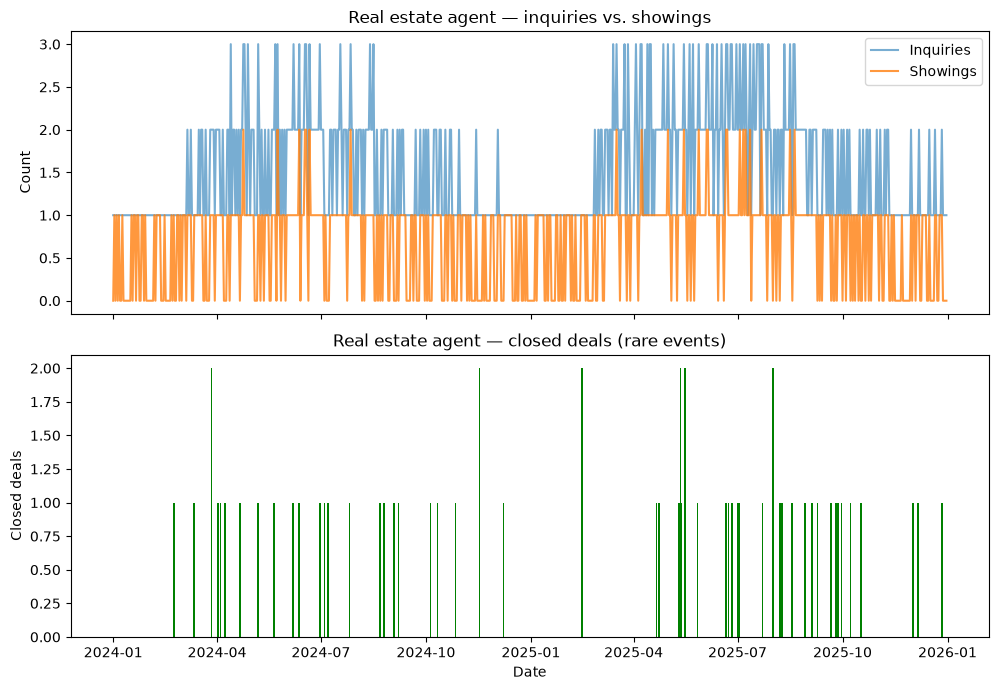

In [13]:
# Dedicated generators for this cell — seed 111. Immune to how many times this or any other cell gets re-run; only this cell's own code changes its output.
cell11_rng = random.Random(111)
cell11_np_rng = np.random.default_rng(111)

# ---- Inquiries ----
INQUIRY_BASE_WEEKLY = cell11_rng.uniform(3, 10)
INQUIRY_BASE_DAILY = INQUIRY_BASE_WEEKLY / 7

def cell11_followers_on_date(date):
    """Local copy of Cell 4's growth-trend formula, using this cell's own dedicated generator instead of the shared global state — see Cell 10's matching note."""
    base = CLIENT_FOLLOWERS["real_estate_agent"]
    growth_rate = CLIENT_GROWTH_RATE["real_estate_agent"]
    progress = (date - START_DATE).days / (END_DATE - START_DATE).days
    trend_value = base * (1 + growth_rate * progress)
    noise = cell11_np_rng.normal(loc=1.0, scale=0.003)
    return int(trend_value * noise)

def re_growth_factor(date):
    baseline_followers = CLIENT_FOLLOWERS["real_estate_agent"]
    actual_followers = cell11_followers_on_date(date)
    return actual_followers / baseline_followers

daily_engagements_re = (
    final_df[final_df["client"] == "real_estate_agent"]
    .groupby("date")["total_engagements"].sum()
    .reindex(ALL_DATES, fill_value=0)
)
avg_engagement_re = daily_engagements_re.mean()
engagement_boost_re = 1 + 0.3 * (daily_engagements_re / avg_engagement_re - 1)
engagement_boost_re = engagement_boost_re.fillna(1.0).clip(0.8, 1.3)

def inquiries_on_date(date):
    growth = re_growth_factor(date)
    season = seasonal_multiplier("real_estate_agent", date)
    boost = engagement_boost_re.loc[date]
    noise = cell11_np_rng.normal(loc=1.0, scale=0.12)
    inquiries = INQUIRY_BASE_DAILY * growth * season * boost * noise
    return max(0, int(round(inquiries)))

re_df = pd.DataFrame({"date": ALL_DATES})
re_df["inquiries"] = re_df["date"].apply(inquiries_on_date)

# ---- Showings ----
SHOWING_RATE_BASE = cell11_rng.uniform(0.45, 0.65)
showing_rate_noise = np.clip(cell11_np_rng.normal(1.0, 0.10, len(ALL_DATES)), 0.5, 1.5)
showing_rate = np.clip(SHOWING_RATE_BASE * showing_rate_noise, 0.20, 0.90)

re_df["showings"] = np.minimum(
    np.round(re_df["inquiries"].values * showing_rate).astype(int),
    re_df["inquiries"].values
)

# ---- Closed deals (lagged ~35 days behind showings, Poisson-drawn) ----
CLOSE_RATE_PER_SHOWING = cell11_rng.uniform(0.06, 0.12)
CLOSING_LAG_DAYS = 35

lagged_showings = re_df["showings"].shift(CLOSING_LAG_DAYS, fill_value=0)
expected_daily_closes = lagged_showings.values * CLOSE_RATE_PER_SHOWING
re_df["closed_deals"] = cell11_np_rng.poisson(lam=np.clip(expected_daily_closes, 0, None))

# ---- Shared schema: primary outcome ----
re_df["primary_outcome_count"] = re_df["closed_deals"]
re_df["primary_outcome_label"] = "Closed Deals"

# ---- Integrity checks ----
showings_le_inquiries = (re_df["showings"] <= re_df["inquiries"]).all()

print(f"Inquiry base (weekly): {INQUIRY_BASE_WEEKLY:.1f}")
print(f"Showing rate base: {SHOWING_RATE_BASE:.1%}")
print(f"Close rate per showing: {CLOSE_RATE_PER_SHOWING:.1%}")
print(f"Closing lag: {CLOSING_LAG_DAYS} days")
print(f"Showings never exceed inquiries: {showings_le_inquiries}")

re_df["year"] = re_df["date"].dt.year
print("\nInquiries, showings & closed deals by year:")
print(re_df.groupby("year")[["inquiries", "showings", "closed_deals"]].agg(["sum", "mean"]))
print(f"\nTotal closed deals over 2 years: {re_df['closed_deals'].sum()}")
print(f"Days with at least 1 closed deal: {(re_df['closed_deals'] > 0).sum()} of {len(re_df)}")
re_df.drop(columns="year", inplace=True)

# ---- Visual check ----
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].plot(re_df["date"], re_df["inquiries"], alpha=0.6, label="Inquiries")
axes[0].plot(re_df["date"], re_df["showings"], alpha=0.8, label="Showings")
axes[0].set_title("Real estate agent — inquiries vs. showings")
axes[0].set_ylabel("Count"); axes[0].legend()
axes[1].bar(re_df["date"], re_df["closed_deals"], width=1.5, color="green")
axes[1].set_title("Real estate agent — closed deals (rare events)")
axes[1].set_ylabel("Closed deals"); axes[1].set_xlabel("Date")
plt.tight_layout(); plt.show()

## Cell 12: Vlogger — Ad Revenue, Sponsorship, Unified Monetization, Primary Outcome

Lightweight monetization layer for the vlogger: a single `est_monetization` figure combining ad revenue (continuous, views-driven) and sponsorship (episodic, per-post) — not two separate systems.

1. **Ad revenue** — scales directly off the vlogger's actual daily reach from `final_df` (blended RPM of $0.3-1.5 per 1,000 views — kept low because the figure blends YouTube with TikTok/Instagram, which monetize at a small fraction of YouTube's per-view rate). Reach already carries growth, seasonality, and the algorithm-change dip from Cell 6, so all three effects flow into ad revenue automatically with no extra code — the dip shows up as a ~32% ad-revenue drop during the dip window, matching the -30% multiplier closely.
2. **Sponsorship** — 3-8% of individual posts are flagged sponsored, valued at $0.002-0.007 per follower (scales with channel size, keeping per-post values believable across the full 200K-4M follower range rather than a flat dollar amount that would look wrong at either end). Uses its own local `cell12_followers_on_date` generator (same pattern as Cells 10-11), so this cell stays fully reproducible on its own re-runs.
3. **`primary_outcome_count` / `primary_outcome_label`** — Est. Revenue (a dollar figure, unlike the chiropractor's/real estate's count-based primary outcomes) — the vlogger's natural bottom-line metric is monetization, not a visit or deal count, so the label reflects what's actually being measured rather than forcing a uniform unit across clients.

Ad RPM base: $0.88 per 1,000 views
Sponsorship rate: 6.3% of posts (96 of 1569 posts)
Sponsorship value rate: $0.005 per follower per sponsored post

Ad revenue, sponsorship revenue & total monetization by year:
     ad_revenue              sponsorship_revenue               \
            sum         mean                 sum         mean   
year                                                            
2024  538768.93  1472.046257           961670.91  2627.516148   
2025  626001.54  1715.072712           918499.14  2516.436000   

     est_monetization               
                  sum         mean  
year                                
2024       1500439.84  4099.562404  
2025       1544500.68  4231.508712  

Total monetization never less than ad revenue alone: True


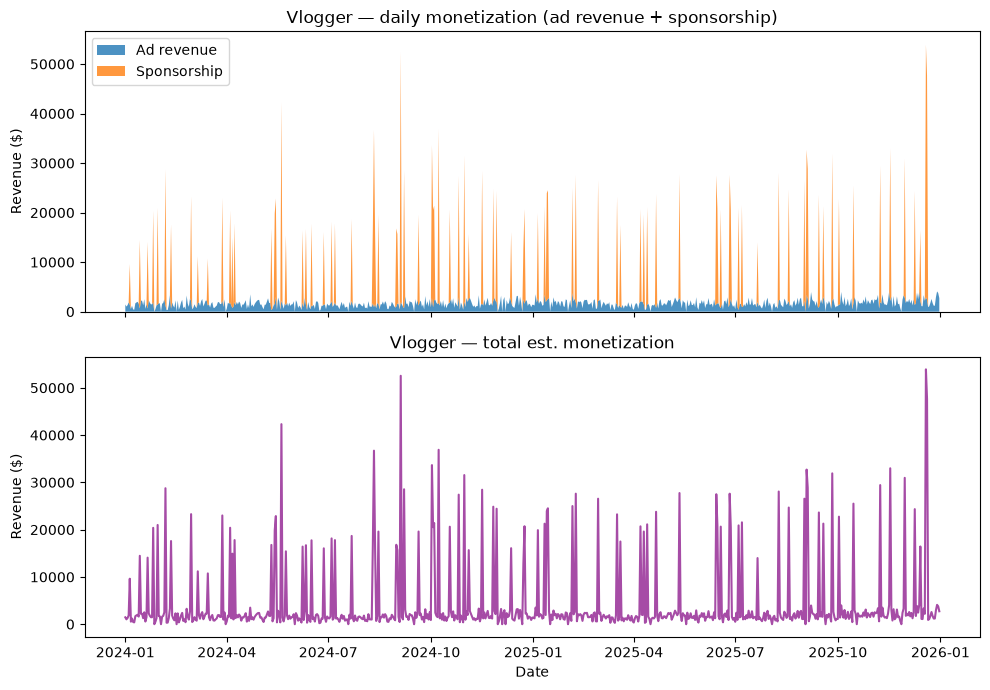

In [14]:
# Dedicated generators for this cell — seed 112. Immune to how many times this or any other cell gets re-run; only this cell's own code changes its output.
cell12_rng = random.Random(112)
cell12_np_rng = np.random.default_rng(112)

# ---- Ad revenue (scales with daily views/reach, RPM-based) ----
daily_reach_vlogger = (
    final_df[final_df["client"] == "vlogger"]
    .groupby("date")["reach"].sum()
    .reindex(ALL_DATES, fill_value=0)
)

AD_RPM_BASE = cell12_rng.uniform(0.3, 1.5)  # $ per 1,000 views, blended across YouTube/TikTok/Instagram (blended low: TikTok/Instagram monetize at a fraction of YouTube's per-view rate)
rpm_noise = np.clip(cell12_np_rng.normal(1.0, 0.15, len(ALL_DATES)), 0.5, 1.5)

vlog_df = pd.DataFrame({"date": ALL_DATES})
vlog_df["ad_revenue"] = (daily_reach_vlogger.values / 1000 * AD_RPM_BASE * rpm_noise).round(2)

# ---- Sponsorship spikes (per-post, follower-scaled) ----
SPONSORSHIP_RATE = cell12_rng.uniform(0.03, 0.08)                  # share of posts that are sponsored
SPONSORSHIP_RATE_PER_FOLLOWER = cell12_rng.uniform(0.002, 0.007)   # $ per follower, per sponsored post

vlogger_posts = final_df[final_df["client"] == "vlogger"][["date"]].copy()
vlogger_posts["is_sponsored"] = cell12_np_rng.random(len(vlogger_posts)) < SPONSORSHIP_RATE

def cell12_followers_on_date(date):
    """Local copy of Cell 4's growth-trend formula, using this cell's own dedicated generator instead of the shared global state — see Cell 10's matching note."""
    base = CLIENT_FOLLOWERS["vlogger"]
    growth_rate = CLIENT_GROWTH_RATE["vlogger"]
    progress = (date - START_DATE).days / (END_DATE - START_DATE).days
    trend_value = base * (1 + growth_rate * progress)
    noise = cell12_np_rng.normal(loc=1.0, scale=0.003)
    return int(trend_value * noise)

def sponsorship_value(row):
    if not row["is_sponsored"]:
        return 0.0
    followers = cell12_followers_on_date(row["date"])
    noise = cell12_np_rng.normal(1.0, 0.2)
    return max(0.0, followers * SPONSORSHIP_RATE_PER_FOLLOWER * noise)

vlogger_posts["sponsorship_value"] = vlogger_posts.apply(sponsorship_value, axis=1)

daily_sponsorship = (
    vlogger_posts.groupby("date")["sponsorship_value"].sum()
    .reindex(ALL_DATES, fill_value=0.0)
)
vlog_df["sponsorship_revenue"] = daily_sponsorship.values.round(2)

# ---- Unified monetization (single column) ----
vlog_df["est_monetization"] = (vlog_df["ad_revenue"] + vlog_df["sponsorship_revenue"]).round(2)

# ---- Shared schema: primary outcome ----
vlog_df["primary_outcome_count"] = vlog_df["est_monetization"]
vlog_df["primary_outcome_label"] = "Est. Revenue"

# ---- Integrity checks ----
sponsored_count = int(vlogger_posts["is_sponsored"].sum())
total_posts = len(vlogger_posts)

print(f"Ad RPM base: ${AD_RPM_BASE:.2f} per 1,000 views")
print(f"Sponsorship rate: {SPONSORSHIP_RATE:.1%} of posts ({sponsored_count} of {total_posts} posts)")
print(f"Sponsorship value rate: ${SPONSORSHIP_RATE_PER_FOLLOWER:.3f} per follower per sponsored post")

vlog_df["year"] = vlog_df["date"].dt.year
print("\nAd revenue, sponsorship revenue & total monetization by year:")
print(vlog_df.groupby("year")[["ad_revenue", "sponsorship_revenue", "est_monetization"]].agg(["sum", "mean"]))
vlog_df.drop(columns="year", inplace=True)

monetization_ok = (vlog_df["est_monetization"] >= vlog_df["ad_revenue"] - 0.01).all()
print(f"\nTotal monetization never less than ad revenue alone: {monetization_ok}")

# ---- Visual check ----
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].stackplot(vlog_df["date"], vlog_df["ad_revenue"], vlog_df["sponsorship_revenue"],
                   labels=["Ad revenue", "Sponsorship"], alpha=0.8)
axes[0].set_title("Vlogger — daily monetization (ad revenue + sponsorship)")
axes[0].set_ylabel("Revenue ($)"); axes[0].legend()
axes[1].plot(vlog_df["date"], vlog_df["est_monetization"], color="purple", alpha=0.7)
axes[1].set_title("Vlogger — total est. monetization")
axes[1].set_ylabel("Revenue ($)"); axes[1].set_xlabel("Date")
plt.tight_layout(); plt.show()

## Cell 13: Chiropractor — Anomaly Injection (Owner Break)

Injects the chiropractor's anomaly: owner takes a 2-3 week vacation/injury break, posting stops, booking inquiries collapse. Timing is randomly chosen (not tied to a holiday), with a buffer that keeps it clear of the January fitness-spike season and the existing Nov-Dec no-show seasonal dip, so this reads as a distinct, attributable event rather than compounding with a pattern that's already there.

**NOTE — not safely re-runnable:** unlike Cells 7-12, this cell *mutates* `final_df` (drops rows) and `chiro_df` (rescales values) rather than only adding new columns. Re-running it without a full kernel restart + top-to-bottom re-run will suppress the numbers a second time.

1. **Posting cessation** — IG/FB posts falling inside the break window are dropped with high probability (a stray scheduled post might still slip out).
2. **Inquiry suppression** — `booking_inquiries` scaled down to a small fraction of normal during the break (office effectively closed; a few calls/voicemails still land), then a 7-day linear ramp back to baseline.
3. **Downstream recompute** — `completed_visits`, `new_inquiries`, `returning_inquiries`, and `primary_outcome_count` all recomputed from the suppressed inquiries, preserving the existing show-up-rate model and each date's original new/returning ratio.
4. **`chiro_anomaly_meta`** — a metadata dict (client, window, expected direction, affected metrics) captured for the combined anomaly table built once all three anomaly cells are done.

Chiropractor break: 2025-02-08 to 2025-02-21 (14 days), recovery through 2025-02-28
Chiropractor posts in break window: 5 -> 0

Suppression factor during break: 15.3%
New + Returning == booking_inquiries still holds: True
Completed visits never exceeds booking inquiries: True
No negative counts introduced: True

Avg daily booking_inquiries, 14 days before break: 3.93
Avg daily booking_inquiries, during break:          0.21


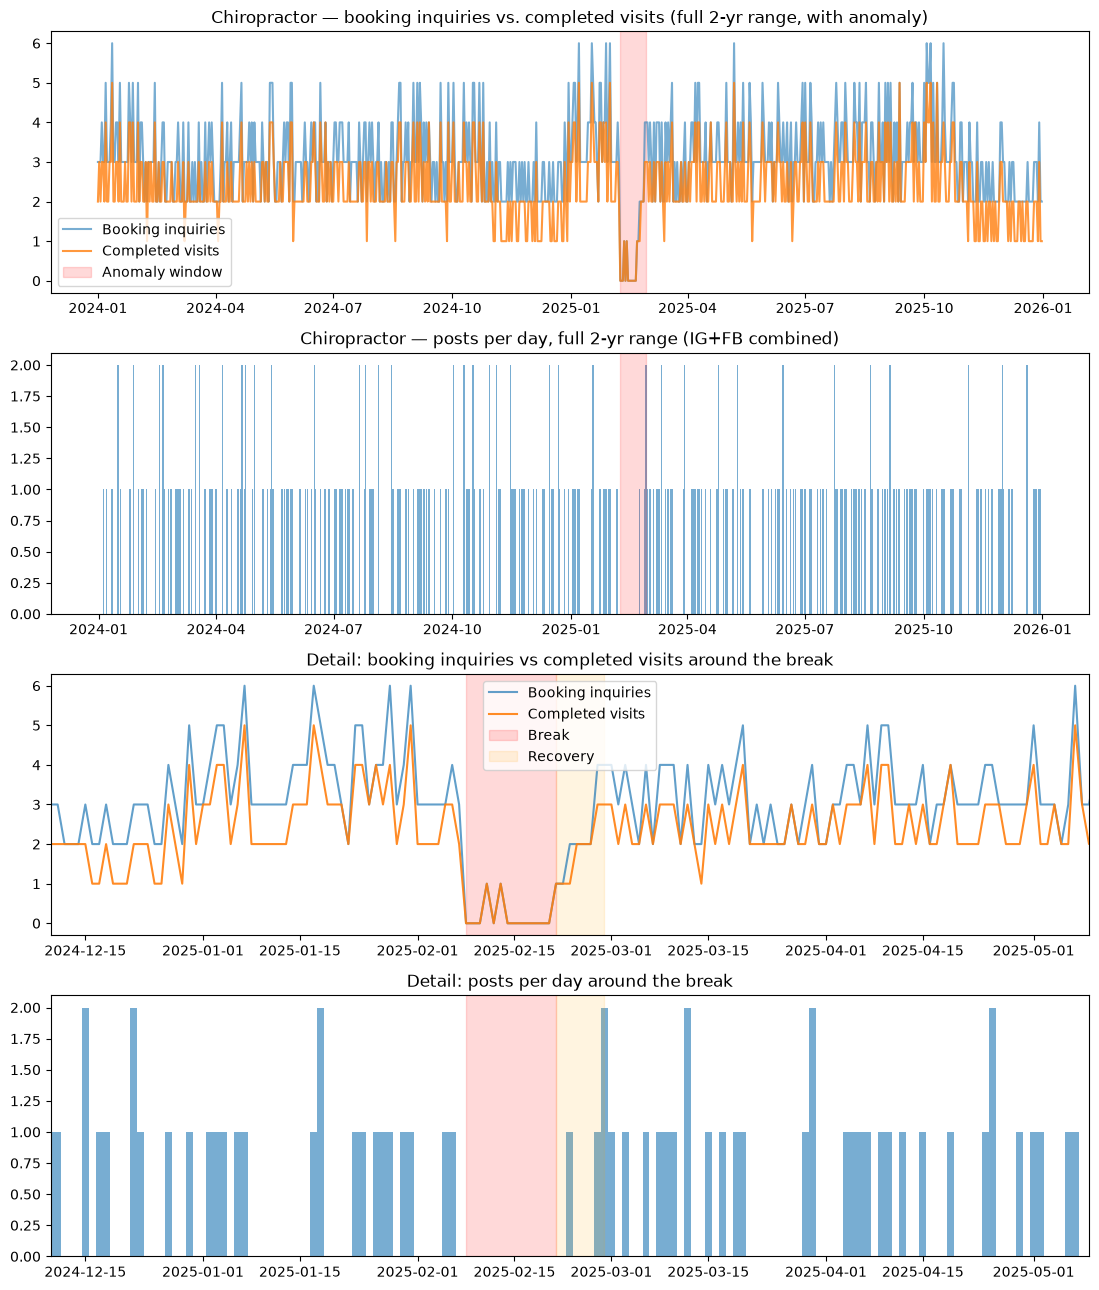

In [15]:
# Dedicated generators for this cell — seed 113. Immune to how many times this or any other cell gets re-run; only this cell's own code changes its output (though this cell itself is not idempotent — it mutates final_df/chiro_df rather than only adding columns).
cell13_rng = random.Random(113)
cell13_np_rng = np.random.default_rng(113)

# ---- Pick anomaly window ----
BREAK_DURATION_DAYS = cell13_rng.randint(14, 21)   # 2-3 weeks
RECOVERY_DAYS = 7                                  # short ramp back to normal

def in_holiday_buffer(d):
    # Skip Nov 15-Jan 31: keeps this anomaly visually distinct from the existing Nov-Dec no-show dip and the January fitness-spike season.
    return (d.month == 12) or (d.month == 11 and d.day >= 15) or (d.month == 1)

buffer_days = 45
candidate_dates = [
    d for d in ALL_DATES
    if (d - START_DATE).days >= buffer_days
    and (END_DATE - d).days >= buffer_days + BREAK_DURATION_DAYS + RECOVERY_DAYS
    and not in_holiday_buffer(d)
]
CHIRO_BREAK_START = cell13_rng.choice(candidate_dates)
CHIRO_BREAK_END = CHIRO_BREAK_START + pd.Timedelta(days=BREAK_DURATION_DAYS - 1)
CHIRO_RECOVERY_END = CHIRO_BREAK_END + pd.Timedelta(days=RECOVERY_DAYS)

print(f"Chiropractor break: {CHIRO_BREAK_START.date()} to {CHIRO_BREAK_END.date()} "
      f"({BREAK_DURATION_DAYS} days), recovery through {CHIRO_RECOVERY_END.date()}")

# ---- Suppress posting (Instagram + Facebook) during the break ----
POST_SURVIVAL_PROB = 0.12  # a scheduled/assistant-posted item might still slip out

is_chiro = final_df["client"] == "chiropractor"
in_break_posts = is_chiro & final_df["date"].between(CHIRO_BREAK_START, CHIRO_BREAK_END)
n_break_posts_before = in_break_posts.sum()

survive_mask = pd.Series(
    cell13_np_rng.random(len(final_df)) < POST_SURVIVAL_PROB, index=final_df.index
)
drop_mask = in_break_posts & ~survive_mask
final_df = final_df[~drop_mask].reset_index(drop=True)

n_break_posts_after = (
    (final_df["client"] == "chiropractor")
    & final_df["date"].between(CHIRO_BREAK_START, CHIRO_BREAK_END)
).sum()
print(f"Chiropractor posts in break window: {n_break_posts_before} -> {n_break_posts_after}")

# ---- Suppress booking inquiries during break + linear recovery ramp ----
INQUIRY_SUPPRESSION = cell13_rng.uniform(0.15, 0.30)  # office effectively closed; a few calls/voicemails still land

def chiro_break_multiplier(date):
    if CHIRO_BREAK_START <= date <= CHIRO_BREAK_END:
        return INQUIRY_SUPPRESSION
    if CHIRO_BREAK_END < date <= CHIRO_RECOVERY_END:
        progress = (date - CHIRO_BREAK_END).days / RECOVERY_DAYS
        return INQUIRY_SUPPRESSION + (1 - INQUIRY_SUPPRESSION) * progress
    return 1.0

break_multiplier = chiro_df["date"].apply(chiro_break_multiplier)

# ---- Preserve each row's original returning-share ratio before touching counts ----
prior_returning_ratio = np.where(
    chiro_df["booking_inquiries"] > 0,
    chiro_df["returning_inquiries"] / chiro_df["booking_inquiries"].replace(0, np.nan),
    0.0,
)
prior_returning_ratio = pd.Series(prior_returning_ratio).ffill().fillna(0.45)

chiro_df["booking_inquiries"] = np.round(chiro_df["booking_inquiries"] * break_multiplier).astype(int)
chiro_df["completed_visits"] = np.round(chiro_df["booking_inquiries"] * chiro_df["show_up_rate"]).astype(int)
chiro_df["returning_inquiries"] = np.round(chiro_df["booking_inquiries"] * prior_returning_ratio).astype(int)
chiro_df["new_inquiries"] = chiro_df["booking_inquiries"] - chiro_df["returning_inquiries"]
chiro_df["primary_outcome_count"] = chiro_df["completed_visits"]

# ---- Anomaly metadata (row for the combined table built once all 3 cells are done) ----
chiro_anomaly_meta = {
    "client": "chiropractor",
    "anomaly_type": "owner break (vacation/injury)",
    "start_date": CHIRO_BREAK_START,
    "end_date": CHIRO_BREAK_END,
    "recovery_end_date": CHIRO_RECOVERY_END,
    "duration_days": BREAK_DURATION_DAYS,
    "expected_direction": "sharp drop",
    "affected_metrics": "posting cadence (IG/FB), booking_inquiries, completed_visits, primary_outcome_count",
}

# ---- Integrity checks ----
split_ok = (chiro_df["new_inquiries"] + chiro_df["returning_inquiries"] == chiro_df["booking_inquiries"]).all()
visits_ok = (chiro_df["completed_visits"] <= chiro_df["booking_inquiries"]).all()
no_negative = (chiro_df[["booking_inquiries", "completed_visits", "new_inquiries", "returning_inquiries"]] >= 0).all().all()

pre_break_avg = chiro_df[chiro_df["date"] < CHIRO_BREAK_START - pd.Timedelta(days=14)].tail(14)
break_window = chiro_df[chiro_df["date"].between(CHIRO_BREAK_START, CHIRO_BREAK_END)]

print(f"\nSuppression factor during break: {INQUIRY_SUPPRESSION:.1%}")
print(f"New + Returning == booking_inquiries still holds: {split_ok}")
print(f"Completed visits never exceeds booking inquiries: {visits_ok}")
print(f"No negative counts introduced: {no_negative}")
print(f"\nAvg daily booking_inquiries, 14 days before break: {pre_break_avg['booking_inquiries'].mean():.2f}")
print(f"Avg daily booking_inquiries, during break:          {break_window['booking_inquiries'].mean():.2f}")

# ---- Visual check: full 2-year panels first (direct before/after comparison), then zoomed detail panels underneath ----
fig, axes = plt.subplots(4, 1, figsize=(11, 13))

axes[0].plot(chiro_df["date"], chiro_df["booking_inquiries"], alpha=0.6, label="Booking inquiries")
axes[0].plot(chiro_df["date"], chiro_df["completed_visits"], alpha=0.8, label="Completed visits")
axes[0].axvspan(CHIRO_BREAK_START, CHIRO_RECOVERY_END, color="red", alpha=0.15, label="Anomaly window")
axes[0].set_title("Chiropractor — booking inquiries vs. completed visits (full 2-yr range, with anomaly)")
axes[0].legend()

chiro_posts = final_df[final_df["client"] == "chiropractor"]
daily_post_counts = chiro_posts.groupby("date").size().reindex(ALL_DATES, fill_value=0)
axes[1].bar(daily_post_counts.index, daily_post_counts.values, width=1.0, alpha=0.6)
axes[1].axvspan(CHIRO_BREAK_START, CHIRO_RECOVERY_END, color="red", alpha=0.15)
axes[1].set_title("Chiropractor — posts per day, full 2-yr range (IG+FB combined)")

axes[2].plot(chiro_df["date"], chiro_df["booking_inquiries"], alpha=0.7, label="Booking inquiries")
axes[2].plot(chiro_df["date"], chiro_df["completed_visits"], alpha=0.9, label="Completed visits")
axes[2].axvspan(CHIRO_BREAK_START, CHIRO_BREAK_END, color="red", alpha=0.15, label="Break")
axes[2].axvspan(CHIRO_BREAK_END, CHIRO_RECOVERY_END, color="orange", alpha=0.12, label="Recovery")
axes[2].set_title("Detail: booking inquiries vs completed visits around the break")
axes[2].legend()
axes[2].set_xlim(CHIRO_BREAK_START - pd.Timedelta(days=60), CHIRO_BREAK_START + pd.Timedelta(days=90))

axes[3].bar(daily_post_counts.index, daily_post_counts.values, width=1.0, alpha=0.6)
axes[3].axvspan(CHIRO_BREAK_START, CHIRO_BREAK_END, color="red", alpha=0.15)
axes[3].axvspan(CHIRO_BREAK_END, CHIRO_RECOVERY_END, color="orange", alpha=0.12)
axes[3].set_title("Detail: posts per day around the break")
axes[3].set_xlim(CHIRO_BREAK_START - pd.Timedelta(days=60), CHIRO_BREAK_START + pd.Timedelta(days=90))

plt.tight_layout(); plt.show()

## Cell 14: Real Estate Agent — Anomaly Injection (Personal Gap Compounding Winter Low)

Injects the real estate agent's anomaly: a personal gap that compounds the already-slow winter season (Dec/Jan/Feb, seasonal multiplier 0.75) rather than reading as a separate event. Window is forced into 2024 specifically — the chiropractor's break (Cell 13) already landed in 2025, so pinning this one to 2024 keeps the two anomalies staggered across different years rather than leaving it to chance.

**NOTE — not safely re-runnable**, same caveat as Cell 13: this cell mutates `final_df` and `re_df` in place. Requires a full kernel restart + top-to-bottom re-run if it needs to run twice.

1. **Posting** — lighter suppression than the chiropractor (35% survival vs. 12%): a personal gap, not a full shutdown, so some pre-scheduled listing content still goes out.
2. **Inquiries** — suppressed during the window, then a 7-day linear recovery ramp, same pattern as Cell 13.
3. **Showings** — recomputed from the suppressed inquiries using the existing showing rate; no separate suppression needed.
4. **Closed deals** — suppressed via **binomial thinning of the original draws** (not an independent Poisson redraw). Rare-event caveat: an independent redraw at a lower lambda isn't guaranteed to go down — it can land higher by chance, which it did on the first pass. Thinning the original counts can only ever reduce them, and it's the more honest model anyway: fewer showings feeding the pipeline means some already-likely closes don't materialize.
5. **`re_anomaly_meta`** — expected direction is recorded per-metric rather than as one blanket claim: inquiries/showings get a guaranteed deterministic drop, closed_deals gets a real-but-noisier reduction (small sample, ~3-week lagged window).

Real estate gap: 2024-12-07 to 2024-12-17 (11 days), recovery through 2024-12-24
Real estate posts in gap window: 5 -> 0

Inquiry suppression factor during gap: 37.0%
Showings never exceeds inquiries still holds: True
No negative counts introduced: True
Closed deals outside the affected +35d window are untouched: True
Closed deals inside the affected window never exceed original (monotonic dip): True

Avg daily inquiries, 14 days before gap: 1.07
Avg daily inquiries, during gap:          0.00

Inquiries, showings & closed deals by year (post-anomaly):
      inquiries  showings  closed_deals
year                                   
2024        504       229            27
2025        586       277            34

Total closed deals over 2 years (post-anomaly): 61


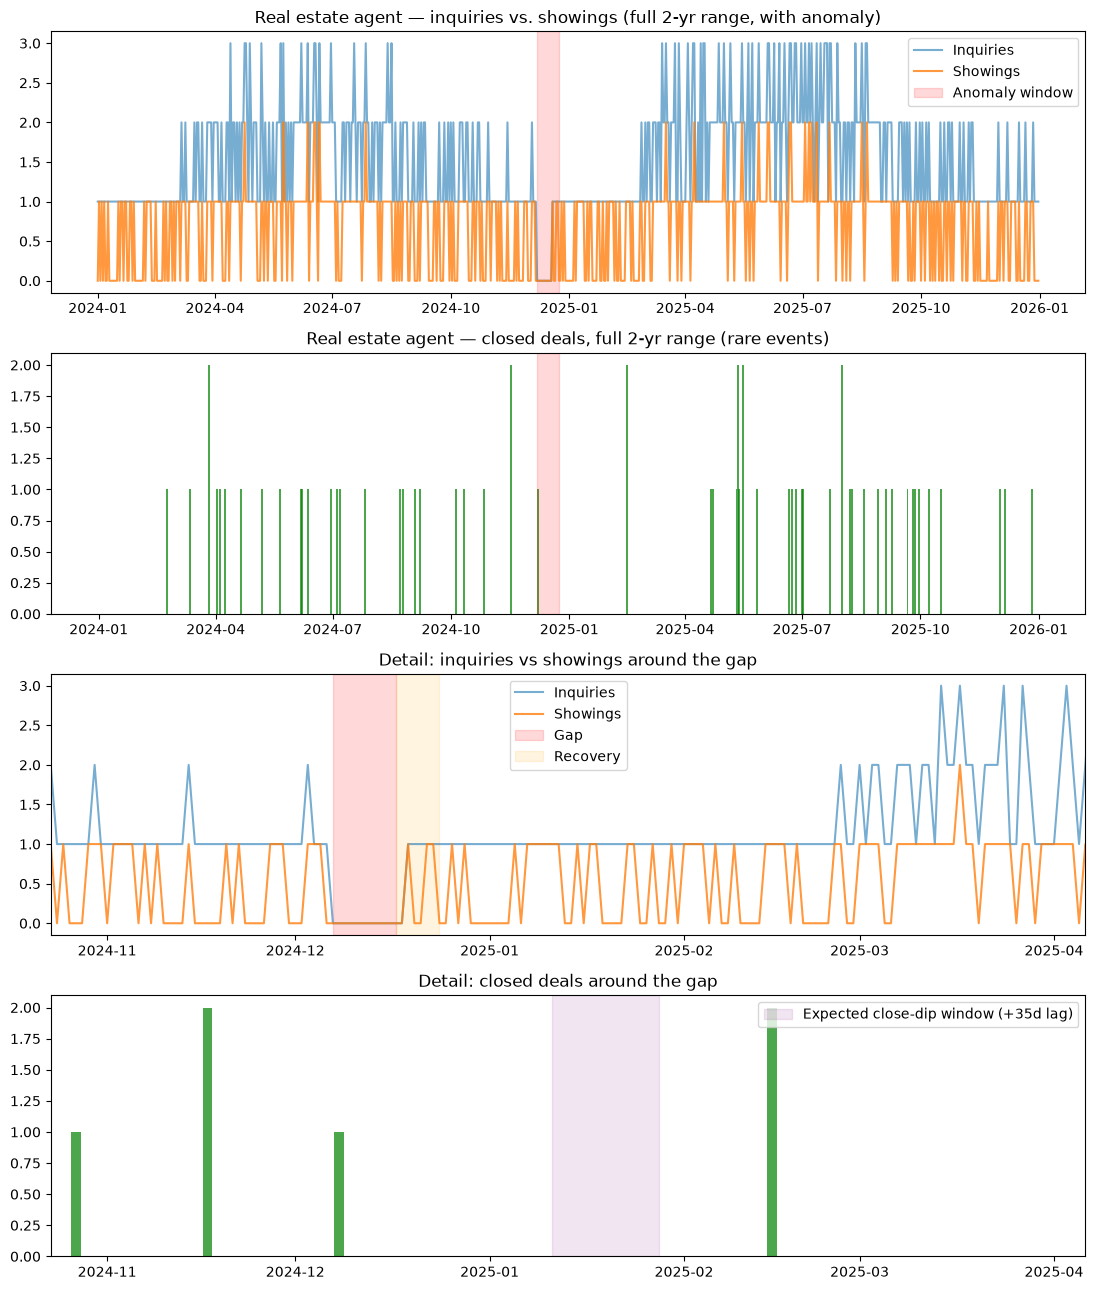

In [16]:
# Dedicated generators for this cell — seed 114. Immune to how many times this or any other cell gets re-run; only this cell's own code changes its output (this cell is not idempotent — it mutates final_df/re_df rather than only adding columns).
cell14_rng = random.Random(114)
cell14_np_rng = np.random.default_rng(114)

# ---- Pick anomaly window: must land in the already-slow winter months (Dec/Jan/Feb, multiplier 0.75) so this compounds the existing seasonal low ----
GAP_DURATION_DAYS = cell14_rng.randint(10, 16)
RE_RECOVERY_DAYS = 7

buffer_start = 30
buffer_end = 30 + CLOSING_LAG_DAYS + RE_RECOVERY_DAYS + GAP_DURATION_DAYS

# Restricted to 2024: the chiropractor's break already landed in 2025 (Cell 13), so pinning this one to 2024 keeps the two anomalies staggered across different years rather than leaving it to chance.
candidate_dates_re = [
    d for d in ALL_DATES
    if d.month in (12, 1, 2)
    and d.year == 2024
    and (d - START_DATE).days >= buffer_start
    and (END_DATE - d).days >= buffer_end
]
RE_GAP_START = cell14_rng.choice(candidate_dates_re)
RE_GAP_END = RE_GAP_START + pd.Timedelta(days=GAP_DURATION_DAYS - 1)
RE_RECOVERY_END = RE_GAP_END + pd.Timedelta(days=RE_RECOVERY_DAYS)

print(f"Real estate gap: {RE_GAP_START.date()} to {RE_GAP_END.date()} "
      f"({GAP_DURATION_DAYS} days), recovery through {RE_RECOVERY_END.date()}")

# ---- Reduce (not eliminate) posting on Facebook/YouTube during the gap ----
POST_SURVIVAL_PROB_RE = 0.35  # some pre-scheduled listing walkthroughs still post

is_re = final_df["client"] == "real_estate_agent"
in_gap_posts = is_re & final_df["date"].between(RE_GAP_START, RE_GAP_END)
n_gap_posts_before = in_gap_posts.sum()

survive_mask_re = pd.Series(
    cell14_np_rng.random(len(final_df)) < POST_SURVIVAL_PROB_RE, index=final_df.index
)
drop_mask_re = in_gap_posts & ~survive_mask_re
final_df = final_df[~drop_mask_re].reset_index(drop=True)

n_gap_posts_after = (
    (final_df["client"] == "real_estate_agent")
    & final_df["date"].between(RE_GAP_START, RE_GAP_END)
).sum()
print(f"Real estate posts in gap window: {n_gap_posts_before} -> {n_gap_posts_after}")

# ---- Suppress inquiries during gap + linear recovery ramp ----
INQUIRY_SUPPRESSION_RE = cell14_rng.uniform(0.35, 0.55)

def re_gap_multiplier(date):
    if RE_GAP_START <= date <= RE_GAP_END:
        return INQUIRY_SUPPRESSION_RE
    if RE_GAP_END < date <= RE_RECOVERY_END:
        progress = (date - RE_GAP_END).days / RE_RECOVERY_DAYS
        return INQUIRY_SUPPRESSION_RE + (1 - INQUIRY_SUPPRESSION_RE) * progress
    return 1.0

gap_multiplier_re = re_df["date"].apply(re_gap_multiplier)
re_df["inquiries"] = np.round(re_df["inquiries"] * gap_multiplier_re).astype(int)

# ---- Recompute showings from suppressed inquiries (same showing_rate as Cell 11) ----
original_re_showings = re_df["showings"].copy()
re_df["showings"] = np.minimum(
    np.round(re_df["inquiries"].values * showing_rate).astype(int),
    re_df["inquiries"].values
)

# ---- Suppress closed_deals in the affected +35d-lag window via BINOMIAL THINNING of the original draws, not an independent Poisson redraw. closed_deals is
# a rare event (~0.03-0.09/day baseline) — an independent redraw, even at a lower lambda, has enough variance to land *higher* than the original by chance
# (confirmed: it did, on the first attempt). Thinning each original count by the same suppression ratio applied to showings can only ever reduce the count,
# never increase it — and it's the mechanistically correct model besides: fewer showings feeding the pipeline means some already-likely closes don't materialize.
original_closed_deals_re = re_df["closed_deals"].copy()
lagged_showings_re = re_df["showings"].shift(CLOSING_LAG_DAYS, fill_value=0)
lagged_showings_original = original_re_showings.shift(CLOSING_LAG_DAYS, fill_value=0)

expected_new = lagged_showings_re.values * CLOSE_RATE_PER_SHOWING
expected_original = lagged_showings_original.values * CLOSE_RATE_PER_SHOWING
ratio = np.divide(expected_new, expected_original, out=np.ones_like(expected_new), where=expected_original > 0)
thinning_prob = np.clip(ratio, 0, 1)

affected_close_start = RE_GAP_START + pd.Timedelta(days=CLOSING_LAG_DAYS)
affected_close_end = RE_RECOVERY_END + pd.Timedelta(days=CLOSING_LAG_DAYS)
affected_close_mask = re_df["date"].between(affected_close_start, affected_close_end)

thinned = cell14_np_rng.binomial(original_closed_deals_re.values, thinning_prob)
re_df["closed_deals"] = np.where(affected_close_mask, thinned, original_closed_deals_re)
re_df["primary_outcome_count"] = re_df["closed_deals"]

unaffected_unchanged = (
    re_df.loc[~affected_close_mask, "closed_deals"].values
    == original_closed_deals_re.loc[~affected_close_mask].values
).all()
dip_is_monotonic = (
    re_df.loc[affected_close_mask, "closed_deals"].values
    <= original_closed_deals_re.loc[affected_close_mask].values
).all()

# ---- Anomaly metadata (row for the combined table built once all 3 cells are done) ----
re_anomaly_meta = {
    "client": "real_estate_agent",
    "anomaly_type": "personal gap compounding winter seasonal low",
    "start_date": RE_GAP_START,
    "end_date": RE_GAP_END,
    "recovery_end_date": RE_RECOVERY_END,
    "duration_days": GAP_DURATION_DAYS,
    "expected_direction": "inquiries/showings: sharp deterministic drop. closed_deals: reduced but noisier (rare-event count, ~3wk lagged window)",
    "affected_metrics": "posting cadence (FB/YT), inquiries, showings, closed_deals (via 35-day lag, thinned not redrawn), primary_outcome_count",
}

# ---- Integrity checks ----
showings_ok_re = (re_df["showings"] <= re_df["inquiries"]).all()
no_negative_re = (re_df[["inquiries", "showings", "closed_deals"]] >= 0).all().all()

pre_gap_avg = re_df[re_df["date"] < RE_GAP_START - pd.Timedelta(days=14)].tail(14)
gap_window = re_df[re_df["date"].between(RE_GAP_START, RE_GAP_END)]

print(f"\nInquiry suppression factor during gap: {INQUIRY_SUPPRESSION_RE:.1%}")
print(f"Showings never exceeds inquiries still holds: {showings_ok_re}")
print(f"No negative counts introduced: {no_negative_re}")
print(f"Closed deals outside the affected +35d window are untouched: {unaffected_unchanged}")
print(f"Closed deals inside the affected window never exceed original (monotonic dip): {dip_is_monotonic}")
print(f"\nAvg daily inquiries, 14 days before gap: {pre_gap_avg['inquiries'].mean():.2f}")
print(f"Avg daily inquiries, during gap:          {gap_window['inquiries'].mean():.2f}")

re_df["year"] = re_df["date"].dt.year
print("\nInquiries, showings & closed deals by year (post-anomaly):")
print(re_df.groupby("year")[["inquiries", "showings", "closed_deals"]].sum())
print(f"\nTotal closed deals over 2 years (post-anomaly): {re_df['closed_deals'].sum()}")
re_df.drop(columns="year", inplace=True)

# ---- Visual check: full 2-year panel first (direct comparison to Cell 11's before shot), then zoomed detail panels underneath ----
fig, axes = plt.subplots(4, 1, figsize=(11, 13))

axes[0].plot(re_df["date"], re_df["inquiries"], alpha=0.6, label="Inquiries")
axes[0].plot(re_df["date"], re_df["showings"], alpha=0.8, label="Showings")
axes[0].axvspan(RE_GAP_START, RE_RECOVERY_END, color="red", alpha=0.15, label="Anomaly window")
axes[0].set_title("Real estate agent — inquiries vs. showings (full 2-yr range, with anomaly)")
axes[0].legend()

axes[1].bar(re_df["date"], re_df["closed_deals"], width=1.5, color="green", alpha=0.7)
axes[1].axvspan(RE_GAP_START, RE_RECOVERY_END, color="red", alpha=0.15)
axes[1].set_title("Real estate agent — closed deals, full 2-yr range (rare events)")

axes[2].plot(re_df["date"], re_df["inquiries"], alpha=0.6, label="Inquiries")
axes[2].plot(re_df["date"], re_df["showings"], alpha=0.8, label="Showings")
axes[2].axvspan(RE_GAP_START, RE_GAP_END, color="red", alpha=0.15, label="Gap")
axes[2].axvspan(RE_GAP_END, RE_RECOVERY_END, color="orange", alpha=0.12, label="Recovery")
axes[2].set_title("Detail: inquiries vs showings around the gap")
axes[2].legend()
axes[2].set_xlim(RE_GAP_START - pd.Timedelta(days=45), RE_GAP_START + pd.Timedelta(days=120))

axes[3].bar(re_df["date"], re_df["closed_deals"], width=1.5, color="green", alpha=0.7)
lag_window_start = RE_GAP_START + pd.Timedelta(days=CLOSING_LAG_DAYS)
lag_window_end = RE_RECOVERY_END + pd.Timedelta(days=CLOSING_LAG_DAYS)
axes[3].axvspan(lag_window_start, lag_window_end, color="purple", alpha=0.1, label="Expected close-dip window (+35d lag)")
axes[3].set_title("Detail: closed deals around the gap")
axes[3].legend()
axes[3].set_xlim(RE_GAP_START - pd.Timedelta(days=45), RE_GAP_START + pd.Timedelta(days=120))

plt.tight_layout(); plt.show()

## Cell 15: Aesthetician — Anomaly Injection (Negative Review-Cycle Shock)

Injects the aesthetician's anomaly: a negative review cycle that hits trust at the point of purchase, not top-of-funnel interest. Unlike Cells 13-14, this is a pure **conversion-side** shock — sessions, traffic mix, and posting cadence are all deliberately left untouched; only `non_social_conversion_rate` and `social_conversion_rate` are suppressed.

**Window is hardcoded, not randomly drawn** (same precedent as the vlogger's `ALGO_DIP_START` in Cell 5): Nov 15 - Dec 8, 2025, deliberately chosen to run through BFCM. This is the most realistic and most damaging timing for this kind of shock, and it produces the sharper, more honest version of the lesson: **BFCM's traffic surge is large enough that raw order counts stay roughly flat through the shock — the anomaly is only visible in the conversion-rate columns and in the counterfactual shortfall, not in the orders trendline by itself.** A reader who only looks at orders would miss it entirely.

**NOTE — not safely re-runnable**, same caveat as Cells 13-14: mutates `ga_df` in place. Requires a full kernel restart + top-to-bottom re-run if it needs to run twice.

1. **Conversion suppression** — both conversion-rate columns scaled down ~35-50% during the shock, 14-day linear recovery ramp after (slower than Cells 13-14's 7-day ramps — reputation heals slower than a booking gap).
2. **Orders & revenue recomputed** from the suppressed rates, same formula as Cell 9.
3. **`orders_expected_baseline` / `orders_shortfall`** — a counterfactual: what orders would have been at these actual session levels using the *original* unsuppressed conversion rate. This isolates the conversion effect from the traffic effect, which is necessary here specifically because the BFCM overlap masks the effect in raw order counts.
4. **`aesthetician_anomaly_meta`** — `expected_direction` is written to match what actually happens (flat raw orders, sharp shortfall vs. counterfactual), not a generic "drops sharply" claim that wouldn't hold up against this window's own numbers.

Aesthetician review-cycle shock: 2025-11-15 to 2025-12-08 (24 days), recovery through 2025-12-22
BFCM 2025 window (Nov 28 - Dec 1) falls inside the shock: True

Conversion suppression factor during shock: 48.4%
ga_df session columns (baseline/social/total) byte-identical to pre-anomaly: True
Conversion rates still non-negative: True
No negative orders/revenue introduced: True

Avg daily orders, 14 days before shock: 26.93
Avg daily orders, during shock:          27.54
Avg daily orders_shortfall during shock (expected-at-old-rate minus actual): 29.21
Total orders_shortfall over the shock window: 701

BFCM 2025 window (post-anomaly) — sessions vs orders:
          date  baseline_sessions  social_sessions  orders  revenue
697 2025-11-28               2676              183      36  3242.52
698 2025-11-29               2835              533      40  3153.60
699 2025-11-30               3030              237      26  1912.56
700 2025-12-01               3162              457      48  3914.40

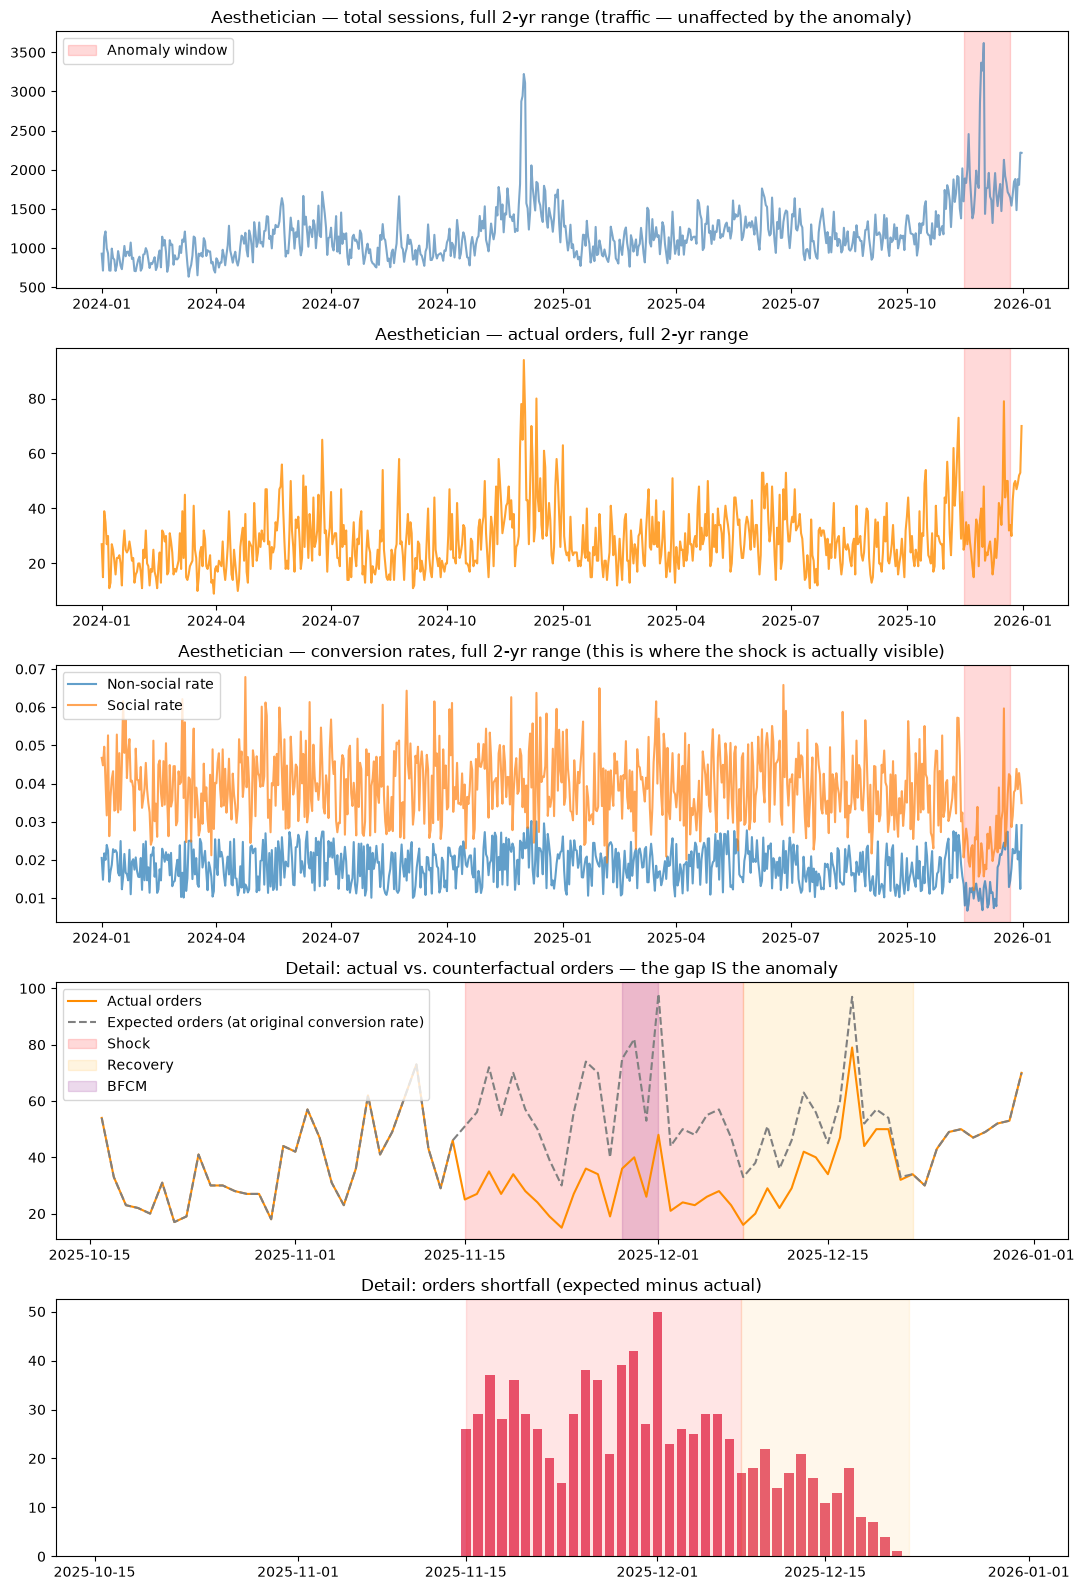

In [17]:
# Dedicated generators for this cell — seed 115. Immune to how many times this or any other cell gets re-run; only this cell's own code changes its output (this cell is not idempotent — it mutates ga_df rather than only adding columns).
cell15_rng = random.Random(115)
cell15_np_rng = np.random.default_rng(115)

# ---- Anomaly window: deliberately hardcoded, not randomly drawn (same precedent as the vlogger's ALGO_DIP_START in Cell 5). A negative-review cycle landing
# right before/through BFCM 2025 is the most damaging, realistic timing for this kind of shock, and produces the sharpest diagnostic story: sessions spike as
# usual for BFCM, but orders don't follow proportionally — the shortfall, not the raw orders trend, is where the anomaly actually shows up.
REVIEW_SHOCK_START = pd.Timestamp(2025, 11, 15)
REVIEW_SHOCK_DURATION_DAYS = 24          # runs through just after BFCM
REVIEW_RECOVERY_DAYS = 14                # reputation heals slower than a technical fix
REVIEW_SHOCK_END = REVIEW_SHOCK_START + pd.Timedelta(days=REVIEW_SHOCK_DURATION_DAYS - 1)
REVIEW_RECOVERY_END = REVIEW_SHOCK_END + pd.Timedelta(days=REVIEW_RECOVERY_DAYS)

print(f"Aesthetician review-cycle shock: {REVIEW_SHOCK_START.date()} to {REVIEW_SHOCK_END.date()} "
      f"({REVIEW_SHOCK_DURATION_DAYS} days), recovery through {REVIEW_RECOVERY_END.date()}")
print(f"BFCM 2025 window (Nov 28 - Dec 1) falls inside the shock: "
      f"{REVIEW_SHOCK_START.date() <= pd.Timestamp(2025,11,28).date() and REVIEW_SHOCK_END.date() >= pd.Timestamp(2025,12,1).date()}")

# ---- NOTE: sessions/traffic and posting cadence are deliberately UNTOUCHED — a reputation problem hits trust at the point of purchase, not top-of-funnel
# interest, so final_df and every *_sessions column in ga_df stay exactly as generated.
CONVERSION_SUPPRESSION = cell15_rng.uniform(0.35, 0.50)

def review_shock_multiplier(date):
    if REVIEW_SHOCK_START <= date <= REVIEW_SHOCK_END:
        return CONVERSION_SUPPRESSION
    if REVIEW_SHOCK_END < date <= REVIEW_RECOVERY_END:
        progress = (date - REVIEW_SHOCK_END).days / REVIEW_RECOVERY_DAYS
        return CONVERSION_SUPPRESSION + (1 - CONVERSION_SUPPRESSION) * progress
    return 1.0

shock_multiplier = ga_df["date"].apply(review_shock_multiplier)

original_orders_ga = ga_df["orders"].copy()
original_revenue_ga = ga_df["revenue"].copy()
original_sessions_snapshot = ga_df[["baseline_sessions", "social_sessions", "total_sessions"]].copy()
original_non_social_rate = ga_df["non_social_conversion_rate"].copy()
original_social_rate = ga_df["social_conversion_rate"].copy()

# ---- Both conversion-rate columns suppressed equally — a trust/reputation issue hits any visitor regardless of which channel brought them to the site ----
ga_df["non_social_conversion_rate"] = ga_df["non_social_conversion_rate"] * shock_multiplier
ga_df["social_conversion_rate"] = ga_df["social_conversion_rate"] * shock_multiplier

orders_non_social = ga_df["baseline_sessions"] * ga_df["non_social_conversion_rate"]
orders_social = ga_df["social_sessions"] * ga_df["social_conversion_rate"]
ga_df["orders"] = (orders_non_social + orders_social).round().astype(int)
ga_df["revenue"] = (ga_df["orders"] * ga_df["aov"]).round(2)
ga_df["primary_outcome_count"] = ga_df["orders"]

# ---- Counterfactual: what orders WOULD have been at these actual session levels using the ORIGINAL unsuppressed conversion rates. Necessary here specifically
# because the shock window overlaps BFCM, where the traffic surge is large enough to mask the conversion collapse in raw order counts (confirmed: actual orders
# during the shock are flat vs. the pre-shock period, purely because ~58% more traffic and ~50% suppressed conversion roughly cancel out numerically). A reader
# looking only at the orders chart would miss the anomaly entirely — the counterfactual gap is what actually makes it visible and honest.
expected_orders_non_social = ga_df["baseline_sessions"] * original_non_social_rate
expected_orders_social = ga_df["social_sessions"] * original_social_rate
ga_df["orders_expected_baseline"] = (expected_orders_non_social + expected_orders_social).round().astype(int)
ga_df["orders_shortfall"] = ga_df["orders_expected_baseline"] - ga_df["orders"]

# ---- Anomaly metadata ----
aesthetician_anomaly_meta = {
    "client": "aesthetician",
    "anomaly_type": "negative review-cycle shock (conversion-side, hits BFCM)",
    "start_date": REVIEW_SHOCK_START,
    "end_date": REVIEW_SHOCK_END,
    "recovery_end_date": REVIEW_RECOVERY_END,
    "duration_days": REVIEW_SHOCK_DURATION_DAYS,
    "expected_direction": "conversion rates drop ~35-50%; raw orders roughly flat (traffic surge masks it); orders_shortfall vs counterfactual is sharply negative",
    "affected_metrics": "non_social_conversion_rate, social_conversion_rate, orders, revenue, orders_expected_baseline, orders_shortfall, primary_outcome_count",
}

# ---- Integrity checks ----
sessions_untouched = (final_df["client"] == "aesthetician").sum()  # compare to your Cell 1-9 confirmed count
rates_ok = (
    (ga_df["non_social_conversion_rate"] >= 0).all() and (ga_df["social_conversion_rate"] >= 0).all()
)
no_negative_orders = (ga_df[["orders", "revenue"]] >= 0).all().all()
sessions_columns_untouched = (
    ga_df[["baseline_sessions", "social_sessions", "total_sessions"]].equals(original_sessions_snapshot)
)

pre_shock_orders = ga_df[ga_df["date"] < REVIEW_SHOCK_START - pd.Timedelta(days=14)].tail(14)
shock_window = ga_df[ga_df["date"].between(REVIEW_SHOCK_START, REVIEW_SHOCK_END)]
bfcm_2025 = ga_df[ga_df["date"].between(pd.Timestamp(2025,11,28), pd.Timestamp(2025,12,1))]

print(f"\nConversion suppression factor during shock: {CONVERSION_SUPPRESSION:.1%}")
print(f"ga_df session columns (baseline/social/total) byte-identical to pre-anomaly: {sessions_columns_untouched}")
print(f"Conversion rates still non-negative: {rates_ok}")
print(f"No negative orders/revenue introduced: {no_negative_orders}")
print(f"\nAvg daily orders, 14 days before shock: {pre_shock_orders['orders'].mean():.2f}")
print(f"Avg daily orders, during shock:          {shock_window['orders'].mean():.2f}")
print(f"Avg daily orders_shortfall during shock (expected-at-old-rate minus actual): {shock_window['orders_shortfall'].mean():.2f}")
print(f"Total orders_shortfall over the shock window: {shock_window['orders_shortfall'].sum()}")
print(f"\nBFCM 2025 window (post-anomaly) — sessions vs orders:")
print(bfcm_2025[["date", "baseline_sessions", "social_sessions", "orders", "revenue"]])

ga_df["year"] = ga_df["date"].dt.year
print("\nOrders & revenue by year (post-anomaly):")
print(ga_df.groupby("year")[["orders", "revenue"]].sum())
ga_df.drop(columns="year", inplace=True)

# ---- Visual check: sessions, actual orders, and conversion rates across the full 2-year range, then a detail view isolating the counterfactual shortfall ----
fig, axes = plt.subplots(5, 1, figsize=(11, 16))

axes[0].plot(ga_df["date"], ga_df["total_sessions"], color="steelblue", alpha=0.7)
axes[0].axvspan(REVIEW_SHOCK_START, REVIEW_RECOVERY_END, color="red", alpha=0.15, label="Anomaly window")
axes[0].set_title("Aesthetician — total sessions, full 2-yr range (traffic — unaffected by the anomaly)")
axes[0].legend()

axes[1].plot(ga_df["date"], ga_df["orders"], color="darkorange", alpha=0.8)
axes[1].axvspan(REVIEW_SHOCK_START, REVIEW_RECOVERY_END, color="red", alpha=0.15)
axes[1].set_title("Aesthetician — actual orders, full 2-yr range")

axes[2].plot(ga_df["date"], ga_df["non_social_conversion_rate"], label="Non-social rate", alpha=0.7)
axes[2].plot(ga_df["date"], ga_df["social_conversion_rate"], label="Social rate", alpha=0.7)
axes[2].axvspan(REVIEW_SHOCK_START, REVIEW_RECOVERY_END, color="red", alpha=0.15)
axes[2].set_title("Aesthetician — conversion rates, full 2-yr range (this is where the shock is actually visible)")
axes[2].legend()

detail = ga_df[ga_df["date"].between(REVIEW_SHOCK_START - pd.Timedelta(days=30), REVIEW_RECOVERY_END + pd.Timedelta(days=30))]
axes[3].plot(detail["date"], detail["orders"], label="Actual orders", color="darkorange")
axes[3].plot(detail["date"], detail["orders_expected_baseline"], label="Expected orders (at original conversion rate)", color="gray", linestyle="--")
axes[3].axvspan(REVIEW_SHOCK_START, REVIEW_SHOCK_END, color="red", alpha=0.15, label="Shock")
axes[3].axvspan(REVIEW_SHOCK_END, REVIEW_RECOVERY_END, color="orange", alpha=0.12, label="Recovery")
axes[3].axvspan(pd.Timestamp(2025,11,28), pd.Timestamp(2025,12,1), color="purple", alpha=0.15, label="BFCM")
axes[3].set_title("Detail: actual vs. counterfactual orders — the gap IS the anomaly")
axes[3].legend()

axes[4].bar(detail["date"], detail["orders_shortfall"], color="crimson", alpha=0.7)
axes[4].axvspan(REVIEW_SHOCK_START, REVIEW_SHOCK_END, color="red", alpha=0.1)
axes[4].axvspan(REVIEW_SHOCK_END, REVIEW_RECOVERY_END, color="orange", alpha=0.08)
axes[4].set_title("Detail: orders shortfall (expected minus actual)")

plt.tight_layout(); plt.show()

## Cell 16: Combined Anomaly Metadata Table

Assembles all four clients' anomalies into one table — the final step of the anomaly injection phase. Three of the four dicts (`chiro_anomaly_meta`, `re_anomaly_meta`, `aesthetician_anomaly_meta`) were already built in Cells 13-15. The vlogger's is added here for the first time — its algorithm dip was always in the notebook (baked into Cell 5's `seasonal_multiplier()`), but never had a matching metadata dict since it wasn't built via its own dedicated anomaly cell.

**`suppression_multiplier` is not on a single consistent scale** — for the three injected anomalies it's a *suppression* factor (lower = more severe, e.g. 0.15 = crushed to 15% of normal). For the vlogger it's `ALGO_DIP_MULTIPLIER` from Cell 5, which is the *same kind* of number (0.70 = reach runs at 70% of normal) but was named/framed differently at its source. Same direction, same meaning, just worth knowing before writing any code that compares these values directly across clients.

Includes an integrity check (all 4 clients present, no missing dates) and a timeline visualization confirming the four windows are staggered across both years without clustering or overlap.

Combined anomaly metadata table:
           client                                             anomaly_type start_date   end_date recovery_end_date  duration_days  suppression_multiplier  year
real_estate_agent             personal gap compounding winter seasonal low 2024-12-07 2024-12-17        2024-12-24             11                0.369577  2024
     chiropractor                            owner break (vacation/injury) 2025-02-08 2025-02-21        2025-02-28             14                0.152681  2025
          vlogger                 algorithm change dip (reach suppression) 2025-03-10 2025-04-14        2025-04-28             35                0.700000  2025
     aesthetician negative review-cycle shock (conversion-side, hits BFCM) 2025-11-15 2025-12-08        2025-12-22             24                0.484385  2025

All 4 clients represented exactly once: True
Years represented: [2024, 2025]
No missing dates: True


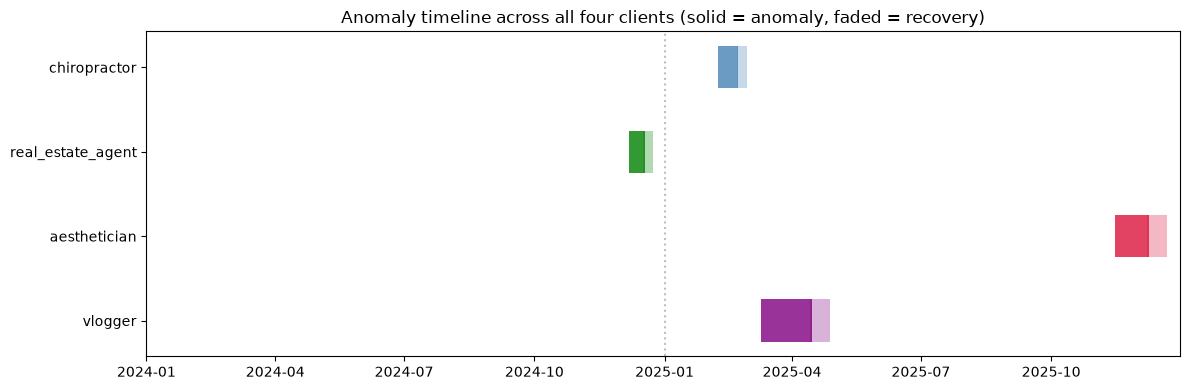

In [18]:
# ---- Vlogger's anomaly metadata: this one was built directly into Cell 5 (the algorithm dip is baked into seasonal_multiplier()), not injected via a
# dedicated Cell 13-15-style cell. Assembling its metadata here for the first time so the table covers all four clients consistently. ----
vlogger_anomaly_meta = {
    "client": "vlogger",
    "anomaly_type": "algorithm change dip (reach suppression)",
    "start_date": ALGO_DIP_START,
    "end_date": ALGO_DIP_END,
    "recovery_end_date": ALGO_DIP_END + timedelta(weeks=ALGO_DIP_RECOVERY_WEEKS),
    "duration_days": (ALGO_DIP_END - ALGO_DIP_START).days,
    "expected_direction": "reach/engagement suppressed ~30%; ad_revenue drops proportionally; "
                           "sponsorship_revenue unaffected (follower-scaled, not reach-based) — "
                           "est_monetization dips but is partially buffered by sponsorship",
    "affected_metrics": "reach, engagements (via seasonal_multiplier), ad_revenue, est_monetization, primary_outcome_count",
}

# ---- Combine all four into one table ----
anomaly_metadata_df = pd.DataFrame([
    chiro_anomaly_meta,
    re_anomaly_meta,
    aesthetician_anomaly_meta,
    vlogger_anomaly_meta,
]).sort_values("start_date").reset_index(drop=True)

anomaly_metadata_df["year"] = pd.to_datetime(anomaly_metadata_df["start_date"]).dt.year

# Pull each cell's own severity value directly rather than re-typing it — keeps this table assertable against the actual numbers each cell used, not a second
# hand-copied source of truth that could drift out of sync.
suppression_by_client = {
    "chiropractor": INQUIRY_SUPPRESSION,
    "real_estate_agent": INQUIRY_SUPPRESSION_RE,
    "aesthetician": CONVERSION_SUPPRESSION,
    "vlogger": ALGO_DIP_MULTIPLIER,
}
anomaly_metadata_df["suppression_multiplier"] = anomaly_metadata_df["client"].map(suppression_by_client)

print("Combined anomaly metadata table:")
print(anomaly_metadata_df[["client", "anomaly_type", "start_date", "end_date",
                            "recovery_end_date", "duration_days", "suppression_multiplier", "year"]].to_string(index=False))

# ---- Integrity checks ----
all_clients_covered = set(anomaly_metadata_df["client"]) == {
    "chiropractor", "real_estate_agent", "aesthetician", "vlogger"
}
years_represented = set(anomaly_metadata_df["year"])
one_per_client = anomaly_metadata_df["client"].value_counts().eq(1).all()
no_missing_dates = anomaly_metadata_df[["start_date", "end_date", "recovery_end_date"]].isna().sum().sum() == 0

print(f"\nAll 4 clients represented exactly once: {all_clients_covered and one_per_client}")
print(f"Years represented: {sorted(years_represented)}")
print(f"No missing dates: {no_missing_dates}")

# ---- Timeline visualization ----
fig, ax = plt.subplots(figsize=(12, 4))
clients_order = ["vlogger", "aesthetician", "real_estate_agent", "chiropractor"]
colors = {"vlogger": "purple", "aesthetician": "crimson", "real_estate_agent": "green", "chiropractor": "steelblue"}

for i, client in enumerate(clients_order):
    row = anomaly_metadata_df[anomaly_metadata_df["client"] == client].iloc[0]
    start = pd.Timestamp(row["start_date"])
    end = pd.Timestamp(row["end_date"])
    recovery_end = pd.Timestamp(row["recovery_end_date"])
    ax.barh(i, (end - start).days + 1, left=start, height=0.5, color=colors[client], alpha=0.8, label="Anomaly")
    ax.barh(i, (recovery_end - end).days, left=end, height=0.5, color=colors[client], alpha=0.3)

ax.set_yticks(range(len(clients_order)))
ax.set_yticklabels(clients_order)
ax.set_xlim(START_DATE, END_DATE)
ax.set_title("Anomaly timeline across all four clients (solid = anomaly, faded = recovery)")
ax.axvline(pd.Timestamp(2025, 1, 1), color="gray", linestyle=":", alpha=0.5)
plt.tight_layout(); plt.show()

## Cell 17: Export to CSV

Writes every dataframe out to `../data/` — one level up from this `notebooks/` folder, so `data/` sits as a **sibling** of `notebooks/`, not nested inside it. Layout:

- `data/{youtube,instagram,facebook,tiktok}/` — post-level data, one CSV per platform, all clients on that platform together with a `client` column (matches how the raw tabs in Sheets will be structured — Master Data does the client-splitting downstream via QUERY)
- `data/ga_store/` — aesthetician's full GA/store funnel (`ga_df`)
- `data/conversions/` — the other three clients' daily conversion layers (`chiro_df`, `re_df`, `vlog_df`) — same kind of data as `ga_store` (daily, non-post-level, client-specific)
- `data/anomaly_metadata.csv` — spans all four clients, so it sits at the `data/` root rather than under any single client or platform folder

**Note:** the relative `../data` path assumes the notebook is run from inside `notebooks/`, matching the on-disk project layout — running it from a different working directory (e.g. the project root) would write `data/` to the wrong place.

In [19]:
# ---- Notebook lives in notebooks/, data/ is a sibling folder one level up ----
DATA_ROOT = os.path.join("..", "data")

# ---- Clear any existing data/ folder first, so this is a clean overwrite, not an accumulation
#      of old + new files (e.g. if a filename changes upstream, the old file won't linger) ----
if os.path.exists(DATA_ROOT):
    shutil.rmtree(DATA_ROOT)
os.makedirs(DATA_ROOT, exist_ok=True)

# ---- Post-level data: one CSV per platform, all clients together (Client column already present in final_df) ----
for platform in ["youtube", "instagram", "facebook", "tiktok"]:
    platform_dir = os.path.join(DATA_ROOT, platform)
    os.makedirs(platform_dir, exist_ok=True)
    platform_df = final_df[final_df["platform"] == platform].copy()
    out_path = os.path.join(platform_dir, f"{platform}_posts.csv")
    platform_df.to_csv(out_path, index=False)
    print(f"{out_path}: {len(platform_df)} rows, clients = {sorted(platform_df['client'].unique())}")

# ---- Aesthetician's full GA/store funnel ----
ga_store_dir = os.path.join(DATA_ROOT, "ga_store")
os.makedirs(ga_store_dir, exist_ok=True)
ga_out_path = os.path.join(ga_store_dir, "aesthetician_ga_store.csv")
ga_df.to_csv(ga_out_path, index=False)
print(f"\n{ga_out_path}: {len(ga_df)} rows, {len(ga_df.columns)} columns")

# ---- Other three clients' daily conversion layers ----
conversions_dir = os.path.join(DATA_ROOT, "conversions")
os.makedirs(conversions_dir, exist_ok=True)

conversion_exports = {
    "chiropractor_conversion.csv": chiro_df,
    "real_estate_conversion.csv": re_df,
    "vlogger_monetization.csv": vlog_df,
}
for filename, df in conversion_exports.items():
    out_path = os.path.join(conversions_dir, filename)
    df.to_csv(out_path, index=False)
    print(f"{out_path}: {len(df)} rows, {len(df.columns)} columns")

# ---- Combined anomaly metadata (spans all four clients) ----
anomaly_out_path = os.path.join(DATA_ROOT, "anomaly_metadata.csv")
anomaly_metadata_df.to_csv(anomaly_out_path, index=False)
print(f"\n{anomaly_out_path}: {len(anomaly_metadata_df)} rows")

# ---- Sanity check: row counts add up, no silent drops ----
platform_row_total = sum(
    (final_df["platform"] == p).sum() for p in ["youtube", "instagram", "facebook", "tiktok"]
)
print(f"\nSum of per-platform CSV rows: {platform_row_total}")
print(f"final_df total rows: {len(final_df)}")
print(f"Match: {platform_row_total == len(final_df)}")

../data/youtube/youtube_posts.csv: 672 rows, clients = ['real_estate_agent', 'vlogger']
../data/instagram/instagram_posts.csv: 1053 rows, clients = ['aesthetician', 'chiropractor', 'vlogger']
../data/facebook/facebook_posts.csv: 319 rows, clients = ['chiropractor', 'real_estate_agent']
../data/tiktok/tiktok_posts.csv: 889 rows, clients = ['aesthetician', 'vlogger']

../data/ga_store/aesthetician_ga_store.csv: 731 rows, 18 columns
../data/conversions/chiropractor_conversion.csv: 731 rows, 8 columns
../data/conversions/real_estate_conversion.csv: 731 rows, 6 columns
../data/conversions/vlogger_monetization.csv: 731 rows, 6 columns

../data/anomaly_metadata.csv: 4 rows

Sum of per-platform CSV rows: 2933
final_df total rows: 2933
Match: True
